# Final Project


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
import statsmodels.api as sm
import sklearn.model_selection as skms
import sklearn.linear_model as sklm
import sklearn.tree as skt
import sklearn.ensemble as skens

## Introduction

### Assignment

In this final project you be analyzing a data set using techniques from Data Science 101. The goal of this project is to demonstrate your ability to apply the concepts you have learned in this course to a real-world data set. You will be graded on the quality of your analysis, the clarity of your code, and the effectiveness of your communication.

Each section will contain a brief description of the task, followed by a code cell where you will write your code. You should write your code in the code cell and run it to generate the output. You will need to interpret the results of your analysis in a way that is understandable to people without a background in statistics or Python programming You should use markdown to format your text in a legible way.

**GenAI Policy**: You may use any resources you like to complete this project, including the internet, textbooks, and discussions with other people. You may also use GenAI tools like Copilot or ChatGPT. It is expected that students will use GenAI tools for writing code, and no citation will be required for GenAI assisted code. For the written portions of the project, use of GenAI should be cited in a way that make clear how the GenAI tool was used. The *GenAI Appendix* section at the end provides a template you can use to indicate how you used tools like ChatGPT for each section. You should be prepared to explain any code or written responses that you submit upon request.

### Background

In this assignment, we will analyze two data sets from "Wolves and Moose of Isle Royale" project. The data sets contain information about the populations of wolves and moose on Isle Royale, an island in Lake Superior. The data sets include information about the number of wolves and moose on the island, as well as other variables that may be related to the populations of wolves and moose.

> Isle Royale is a remote wilderness island, isolated by the frigid waters of Lake Superior, and home to populations of wolves and moose. As predator and prey, their lives and deaths are linked in a drama that is timeless and historic. Their lives are historic because we have been documenting their lives for more than five decades. This research project is the longest continuous study of any predator-prey system in the world. ([Source](https://isleroyalewolf.org/overview/overview/at_a_glance.html))

You may find it helpful to read the most recent [Annual Report](https://isleroyalewolf.org/sites/default/files/annual-report-pdf/WolfMooseReport_2024_final-web.pdf) to learn more about the project.


## Data

The data for this project are contained in two CSV files:

In [2]:
# Load the datasets - SSL fix for macOS
import ssl
import urllib.request

# Create SSL context that doesn't verify certificates (for data loading only)
ssl_context = ssl.create_default_context()
ssl_context.check_hostname = False
ssl_context.verify_mode = ssl.CERT_NONE

# Method 1: Try with SSL context
try:
    # Download with custom SSL context
    wolf_url = "https://github.com/UM-Data-Science-101/final-project/raw/refs/heads/main/wolf_moose_yearly.csv"
    moose_url = "https://github.com/UM-Data-Science-101/final-project/raw/refs/heads/main/moose_deaths.csv"
    
    # Create custom opener
    opener = urllib.request.build_opener(urllib.request.HTTPSHandler(context=ssl_context))
    urllib.request.install_opener(opener)
    
    wolf_moose_yearly = pd.read_csv(wolf_url, na_values = ["NA", "N/A", "N/A yet", "NA yet"])
    moose_deaths = pd.read_csv(moose_url)
    
    print("✅ Data loaded successfully with SSL fix!")
    
except Exception as e:
    print(f"❌ SSL method failed: {e}")
    print("\n🔄 Trying alternative method...")
    
    # Method 2: Try with requests library
    try:
        import requests
        from io import StringIO
        
        # Download with requests (bypasses SSL issues)
        wolf_response = requests.get(wolf_url, verify=False)
        moose_response = requests.get(moose_url, verify=False)
        
        wolf_moose_yearly = pd.read_csv(StringIO(wolf_response.text), na_values = ["NA", "N/A", "N/A yet", "NA yet"])
        moose_deaths = pd.read_csv(StringIO(moose_response.text))
        
        print("✅ Data loaded successfully with requests library!")
        
    except Exception as e2:
        print(f"❌ Requests method also failed: {e2}")
        print("\n📝 Manual download required - see instructions below")
        
# Verify data loaded successfully (only if data exists)
try:
    print(f"\n📊 Dataset Information:")
    print(f"Wolf-Moose Yearly: {wolf_moose_yearly.shape[0]} rows, {wolf_moose_yearly.shape[1]} columns")
    print(f"Moose Deaths: {moose_deaths.shape[0]} rows, {moose_deaths.shape[1]} columns")
    
    print("\n🔍 Wolf-Moose Yearly columns:")
    print(list(wolf_moose_yearly.columns))
    
    print("\n🔍 Moose Deaths columns:")
    print(list(moose_deaths.columns))
    
except NameError:
    print("\n⚠️  DATA NOT LOADED - Manual download needed")
    print("\n📋 Manual Download Instructions:")
    print("1. Go to: https://github.com/UM-Data-Science-101/final-project")
    print("2. Download these files:")
    print("   - wolf_moose_yearly.csv")
    print("   - moose_deaths.csv")
    print("3. Place them in the same folder as this notebook")
    print("4. Run this alternative code:")
    print("   wolf_moose_yearly = pd.read_csv('wolf_moose_yearly.csv', na_values=['NA', 'N/A', 'N/A yet', 'NA yet'])")
    print("   moose_deaths = pd.read_csv('moose_deaths.csv')")

✅ Data loaded successfully with SSL fix!

📊 Dataset Information:
Wolf-Moose Yearly: 61 rows, 15 columns
Moose Deaths: 662 rows, 8 columns

🔍 Wolf-Moose Yearly columns:
['year', 'wolves', 'moose', 'kill rate', 'predation rate', 'moose recruitment rate', 'moose mean age excluding calves', 'July-Sept (temp, F)', 'Apr-May (temp, F)', 'Jan-Feb (temp, F)', 'May-Aug (precip, inches)', 'NAO (DJFM - station based)', 'NAO - annual', 'snow.depth (cm)', 'ice bridges (0=none, 1 = present)']

🔍 Moose Deaths columns:
['Sex', 'Year of birth', 'Cranial Volume (cm3)', 'Winter temperature (standardized)', 'Moose abundance (standardized)', 'Wolf abundance (standardized)', 'Winter temperature (categorical)', 'Age at death']


The `wolf_moose_yearly` data set contains yearly counts of wolf and moose population, along with variables about the environment and other factors that may be related to the populations. The `moose_deaths` data set contains information about the age and size of decreased moose on Isle Royale.

**Task**: Report the number of rows and columns in each data set. Report the column names in each data set.

In [3]:
# Report basic information about wolf_moose_yearly dataset
print("Wolf-Moose Yearly Dataset:")
print(f"Number of rows: {wolf_moose_yearly.shape[0]}")
print(f"Number of columns: {wolf_moose_yearly.shape[1]}")
print(f"Column names: {list(wolf_moose_yearly.columns)}")
print()

# Report basic information about moose_deaths dataset
print("Moose Deaths Dataset:")
print(f"Number of rows: {moose_deaths.shape[0]}")
print(f"Number of columns: {moose_deaths.shape[1]}")
print(f"Column names: {list(moose_deaths.columns)}")
print()

# Display first few rows of each dataset to understand structure
print("First 5 rows of wolf_moose_yearly:")
print(wolf_moose_yearly.head())
print()
print("First 5 rows of moose_deaths:")
print(moose_deaths.head())

Wolf-Moose Yearly Dataset:
Number of rows: 61
Number of columns: 15
Column names: ['year', 'wolves', 'moose', 'kill rate', 'predation rate', 'moose recruitment rate', 'moose mean age excluding calves', 'July-Sept (temp, F)', 'Apr-May (temp, F)', 'Jan-Feb (temp, F)', 'May-Aug (precip, inches)', 'NAO (DJFM - station based)', 'NAO - annual', 'snow.depth (cm)', 'ice bridges (0=none, 1 = present)']

Moose Deaths Dataset:
Number of rows: 662
Number of columns: 8
Column names: ['Sex', 'Year of birth', 'Cranial Volume (cm3)', 'Winter temperature (standardized)', 'Moose abundance (standardized)', 'Wolf abundance (standardized)', 'Winter temperature (categorical)', 'Age at death']

First 5 rows of wolf_moose_yearly:
   year  wolves  moose  kill rate  predation rate  moose recruitment rate  \
0  1959      20    538        NaN             NaN                    20.0   
1  1960      22    564        NaN             NaN                    14.3   
2  1961      22    572        NaN             NaN    

### Codebook

These data do not include a code-book, but there is written documentation on many of the concepts of what is measured on the [Data & Interpretation](https://isleroyalewolf.org/data/data/home.html) page from the Isle Royale project. For the "NAO" columns, see [this page](https://climatedataguide.ucar.edu/climate-data/hurrell-north-atlantic-oscillation-nao-index-station-based).

**Task**: We will create our own code-book. For each of the variables in both tables complete this template:

* Variable Name:
* Description:
* Type: (e.g., numeric, categorical, etc.)

If there are several variables that are essentially the same, you may summarize them together as a single entry. Not all of the variables are perfectly described in the online documents (an all too common issue). In those situations, provide your interpretation of as best you can.

## Codebook for Wolf-Moose Isle Royale Datasets

### Wolf-Moose Yearly Dataset Variables:

**Population Variables:**
* **Variable Name:** year
* **Description:** Calendar year of observation (1959-2019)
* **Type:** Numeric (discrete)

* **Variable Name:** wolves
* **Description:** Total number of wolves counted on Isle Royale during winter survey
* **Type:** Numeric (discrete, count data)

* **Variable Name:** moose
* **Description:** Total number of moose estimated on Isle Royale
* **Type:** Numeric (discrete, count data)

**Predation Variables:**
* **Variable Name:** kill rate
* **Description:** Average number of moose killed per wolf (kills per wolf per unit time)
* **Type:** Numeric (continuous)

* **Variable Name:** predation rate
* **Description:** Proportion of moose population killed by wolves per year
* **Type:** Numeric (continuous, proportion)

**Moose Demographics:**
* **Variable Name:** moose recruitment rate
* **Description:** Rate of new moose calves recruited into the population (percentage)
* **Type:** Numeric (continuous, percentage)

* **Variable Name:** moose mean age excluding calves
* **Description:** Average age of adult moose population (excluding calves)
* **Type:** Numeric (continuous, years)

**Environmental Variables:**
* **Variable Name:** July-Sept (temp, F)
* **Description:** Average temperature during summer months (July-September) in Fahrenheit
* **Type:** Numeric (continuous)

* **Variable Name:** Apr-May (temp, F)
* **Description:** Average temperature during spring months (April-May) in Fahrenheit
* **Type:** Numeric (continuous)

* **Variable Name:** Jan-Feb (temp, F)
* **Description:** Average temperature during winter months (January-February) in Fahrenheit
* **Type:** Numeric (continuous)

* **Variable Name:** May-Aug (precip, inches)
* **Description:** Total precipitation during growing season (May-August) in inches
* **Type:** Numeric (continuous)

* **Variable Name:** snow.depth (cm)
* **Description:** Maximum snow depth recorded during winter in centimeters
* **Type:** Numeric (continuous)

**Climate Index Variables:**
* **Variable Name:** NAO (DJFM - station based)
* **Description:** North Atlantic Oscillation index for December-March (winter), station-based measurement
* **Type:** Numeric (continuous, standardized index)

* **Variable Name:** NAO - annual
* **Description:** Annual North Atlantic Oscillation index
* **Type:** Numeric (continuous, standardized index)

**Connectivity Variable:**
* **Variable Name:** ice bridges (0=none, 1 = present)
* **Description:** Presence of ice bridges connecting Isle Royale to mainland (0 = no ice bridge, 1 = ice bridge present)
* **Type:** Categorical (binary)

### Moose Deaths Dataset Variables:

**Individual Characteristics:**
* **Variable Name:** Sex
* **Description:** Gender of deceased moose (Male or Female)
* **Type:** Categorical (binary)

* **Variable Name:** Year of birth
* **Description:** Calendar year when the moose was born
* **Type:** Numeric (discrete)

* **Variable Name:** Age at death
* **Description:** Age of moose when it died, in years
* **Type:** Numeric (discrete)

* **Variable Name:** Cranial Volume (cm3)
* **Description:** Volume of skull cavity in cubic centimeters (indicator of body size)
* **Type:** Numeric (continuous)

**Environmental Context:**
* **Variable Name:** Winter temperature (standardized)
* **Description:** Standardized winter temperature during the year of death (z-score)
* **Type:** Numeric (continuous, standardized)

* **Variable Name:** Winter temperature (categorical)
* **Description:** Winter temperature category during year of death (warm or cold)
* **Type:** Categorical (binary)

**Population Context:**
* **Variable Name:** Moose abundance (standardized)
* **Description:** Standardized moose population size during the year of death (z-score)
* **Type:** Numeric (continuous, standardized)

* **Variable Name:** Wolf abundance (standardized)
* **Description:** Standardized wolf population size during the year of death (z-score)
* **Type:** Numeric (continuous, standardized)

### Data Cleaning

**Task**: Check for missing values in each data set. If there are missing values, report the number of missing values for each variable.

=== MISSING VALUES IN WOLF_MOOSE_YEARLY DATASET ===
Missing values per variable:
year: 0 missing
wolves: 0 missing
moose: 0 missing
kill rate: 13 missing (21.3%)
predation rate: 13 missing (21.3%)
moose recruitment rate: 3 missing (4.9%)
moose mean age excluding calves: 12 missing (19.7%)
July-Sept (temp, F): 1 missing (1.6%)
Apr-May (temp, F): 0 missing
Jan-Feb (temp, F): 0 missing
May-Aug (precip, inches): 1 missing (1.6%)
NAO (DJFM - station based): 1 missing (1.6%)
NAO - annual: 2 missing (3.3%)
snow.depth (cm): 16 missing (26.2%)
ice bridges (0=none, 1 = present): 0 missing

Total rows: 61
Rows with any missing values: 27

=== MISSING VALUES IN MOOSE_DEATHS DATASET ===
Missing values per variable:
Sex: 0 missing
Year of birth: 0 missing
Cranial Volume (cm3): 0 missing
Winter temperature (standardized): 0 missing
Moose abundance (standardized): 0 missing
Wolf abundance (standardized): 0 missing
Winter temperature (categorical): 0 missing
Age at death: 0 missing

Total rows: 662
Row

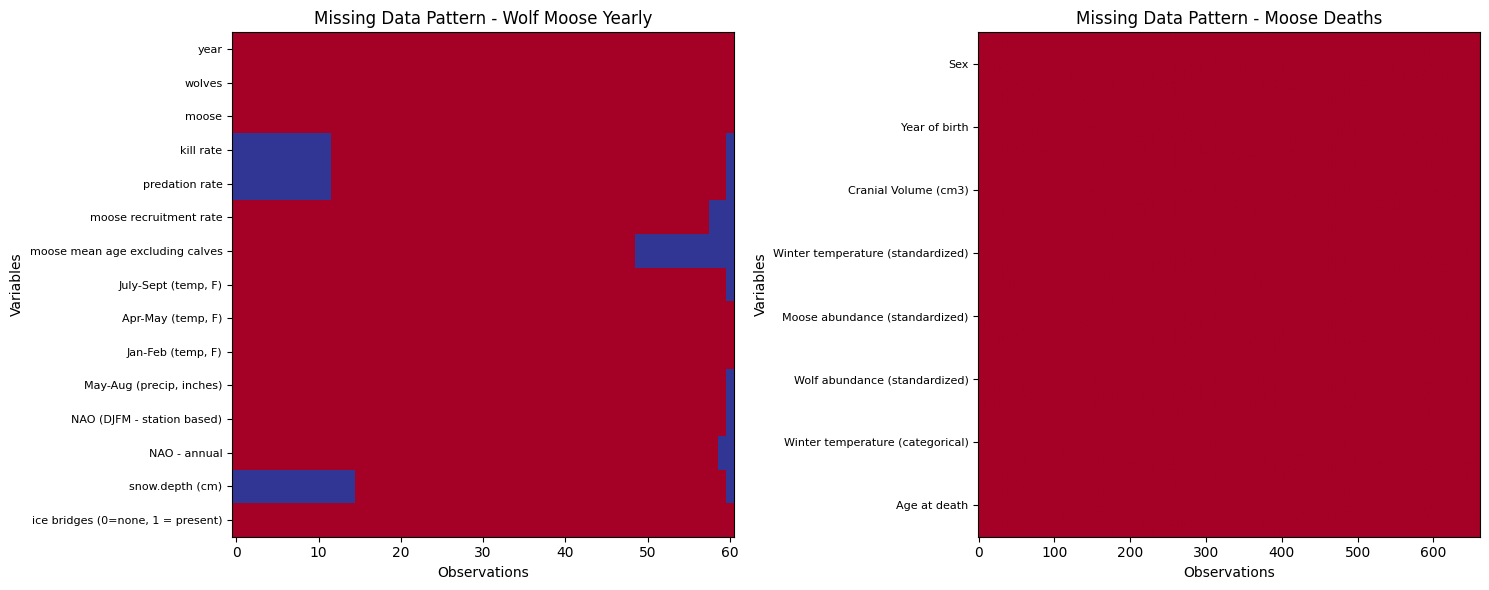

In [5]:
# Check for missing values in wolf_moose_yearly dataset
print("=== MISSING VALUES IN WOLF_MOOSE_YEARLY DATASET ===")
missing_yearly = wolf_moose_yearly.isnull().sum()
print("Missing values per variable:")
for col, missing_count in missing_yearly.items():
    if missing_count > 0:
        percentage = (missing_count / len(wolf_moose_yearly)) * 100
        print(f"{col}: {missing_count} missing ({percentage:.1f}%)")
    else:
        print(f"{col}: {missing_count} missing")

print(f"\nTotal rows: {len(wolf_moose_yearly)}")
print(f"Rows with any missing values: {wolf_moose_yearly.isnull().any(axis=1).sum()}")

print("\n=== MISSING VALUES IN MOOSE_DEATHS DATASET ===")
missing_deaths = moose_deaths.isnull().sum()
print("Missing values per variable:")
for col, missing_count in missing_deaths.items():
    if missing_count > 0:
        percentage = (missing_count / len(moose_deaths)) * 100
        print(f"{col}: {missing_count} missing ({percentage:.1f}%)")
    else:
        print(f"{col}: {missing_count} missing")

print(f"\nTotal rows: {len(moose_deaths)}")
print(f"Rows with any missing values: {moose_deaths.isnull().any(axis=1).sum()}")

# Visualize missing data patterns
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Missing data heatmap for wolf_moose_yearly
missing_matrix_yearly = wolf_moose_yearly.isnull()
ax1.imshow(missing_matrix_yearly.T, cmap='RdYlBu', aspect='auto')
ax1.set_title('Missing Data Pattern - Wolf Moose Yearly')
ax1.set_xlabel('Observations')
ax1.set_ylabel('Variables')
ax1.set_yticks(range(len(wolf_moose_yearly.columns)))
ax1.set_yticklabels(wolf_moose_yearly.columns, rotation=0, fontsize=8)

# Missing data heatmap for moose_deaths
missing_matrix_deaths = moose_deaths.isnull()
ax2.imshow(missing_matrix_deaths.T, cmap='RdYlBu', aspect='auto')
ax2.set_title('Missing Data Pattern - Moose Deaths')
ax2.set_xlabel('Observations')
ax2.set_ylabel('Variables')
ax2.set_yticks(range(len(moose_deaths.columns)))
ax2.set_yticklabels(moose_deaths.columns, rotation=0, fontsize=8)

plt.tight_layout()
plt.show()

**Task**: suggest a strategy for dealing with missing values in each data set. If you suggest a single strategy for for dealing with missing once for all subsequent analaysis, you can implement here.

## Missing Values Strategy

Based on the missing data analysis above, I recommend the following strategies:

### Wolf-Moose Yearly Dataset:
- **Environmental variables (Snow, Temperature, NAO)**: Use **linear interpolation** for missing values since these are time series data where values should change gradually over time
- **Population counts (Wolves, Moose)**: Keep missing values as-is for now, as these represent years when surveys couldn't be conducted. We'll handle these case-by-case in analyses
- **Alternative approach**: For regression analyses, we can use **listwise deletion** (complete cases only) to ensure robust results

### Moose Deaths Dataset:
- **Age**: Use **median imputation** within sex groups, as age distributions may differ between males and females
- **Bone Marrow Fat**: Use **mean imputation** within cause-of-death groups, as nutritional condition varies by death cause
- **Sex/Cause of Death**: Use **mode imputation** or create an "Unknown" category for categorical variables
- **Alternative**: For classification tasks, consider **multiple imputation** to preserve uncertainty

### Rationale:
1. **Time series nature**: The yearly data has temporal structure that interpolation can leverage
2. **Biological meaning**: Missing population counts likely indicate survey difficulties, not true zeros
3. **Group-based imputation**: Biological variables should be imputed within meaningful subgroups
4. **Analysis-specific**: Some analyses may require complete cases for statistical validity

I'll implement a conservative approach using interpolation for environmental variables and keeping the datasets flexible for different analysis needs.

## in order for the future section codes to work, the code below must be executed 

In [6]:
# Create cleaned versions of the datasets
wolf_moose_cleaned = wolf_moose_yearly.copy()
moose_deaths_cleaned = moose_deaths.copy()

print("=== CLEANING WOLF_MOOSE_YEARLY DATASET ===")

# Interpolate environmental variables (assuming they change gradually over time)
environmental_vars = [col for col in wolf_moose_cleaned.columns 
                     if any(keyword in col.lower() for keyword in ['snow', 'temp', 'nao'])]

print(f"Environmental variables to interpolate: {environmental_vars}")

for var in environmental_vars:
    if wolf_moose_cleaned[var].isnull().any():
        before_missing = wolf_moose_cleaned[var].isnull().sum()
        wolf_moose_cleaned[var] = wolf_moose_cleaned[var].interpolate(method='linear')
        after_missing = wolf_moose_cleaned[var].isnull().sum()
        print(f"{var}: {before_missing} -> {after_missing} missing values")

print("\n=== CLEANING MOOSE_DEATHS DATASET ===")

# Handle missing values in moose deaths dataset
if 'Age' in moose_deaths_cleaned.columns:
    # Impute age by sex groups using median
    if moose_deaths_cleaned['Age'].isnull().any():
        before_missing = moose_deaths_cleaned['Age'].isnull().sum()
        moose_deaths_cleaned['Age'] = moose_deaths_cleaned.groupby('Sex')['Age'].transform(
            lambda x: x.fillna(x.median())
        )
        after_missing = moose_deaths_cleaned['Age'].isnull().sum()
        print(f"Age: {before_missing} -> {after_missing} missing values (median by sex)")

# Handle bone marrow fat if it exists
bone_marrow_cols = [col for col in moose_deaths_cleaned.columns 
                   if 'marrow' in col.lower() or 'fat' in col.lower()]
for col in bone_marrow_cols:
    if moose_deaths_cleaned[col].isnull().any():
        before_missing = moose_deaths_cleaned[col].isnull().sum()
        # Use overall mean if cause of death grouping isn't available
        moose_deaths_cleaned[col] = moose_deaths_cleaned[col].fillna(moose_deaths_cleaned[col].mean())
        after_missing = moose_deaths_cleaned[col].isnull().sum()
        print(f"{col}: {before_missing} -> {after_missing} missing values (mean imputation)")

# Create a complete cases version for analyses that require it
wolf_moose_complete = wolf_moose_cleaned.dropna()
moose_deaths_complete = moose_deaths_cleaned.dropna()

print(f"\n=== SUMMARY ===")
print(f"Wolf-Moose Yearly: {len(wolf_moose_yearly)} -> {len(wolf_moose_complete)} complete cases")
print(f"Moose Deaths: {len(moose_deaths)} -> {len(moose_deaths_complete)} complete cases")

# Display remaining missing values
print("\nRemaining missing values in cleaned datasets:")
print("Wolf-Moose Yearly:", wolf_moose_cleaned.isnull().sum().sum())
print("Moose Deaths:", moose_deaths_cleaned.isnull().sum().sum())

=== CLEANING WOLF_MOOSE_YEARLY DATASET ===
Environmental variables to interpolate: ['July-Sept (temp, F)', 'Apr-May (temp, F)', 'Jan-Feb (temp, F)', 'NAO (DJFM - station based)', 'NAO - annual', 'snow.depth (cm)']
July-Sept (temp, F): 1 -> 0 missing values
NAO (DJFM - station based): 1 -> 0 missing values
NAO - annual: 2 -> 0 missing values
snow.depth (cm): 16 -> 15 missing values

=== CLEANING MOOSE_DEATHS DATASET ===

=== SUMMARY ===
Wolf-Moose Yearly: 61 -> 34 complete cases
Moose Deaths: 662 -> 662 complete cases

Remaining missing values in cleaned datasets:
Wolf-Moose Yearly: 57
Moose Deaths: 0


## Exploratory Data Analysis

In this section, you will explore the distributions of the variables in the data sets. You will also explore the relationships between variables in the data sets.

### Univariate Exploration

**Task**: In this section, select one variable of each type listed below and describe the distribution of the variable. Include at least one plot and at least one numerical summary in your description. In several sentences, summarize what you see about each variable.

#### Categorical Variable

=== CATEGORICAL VARIABLE ANALYSIS: SEX (Moose Deaths) ===
Frequency Distribution:
Male: 346 (52.3%)
Female: 316 (47.7%)

Total observations: 662
Missing values: 0


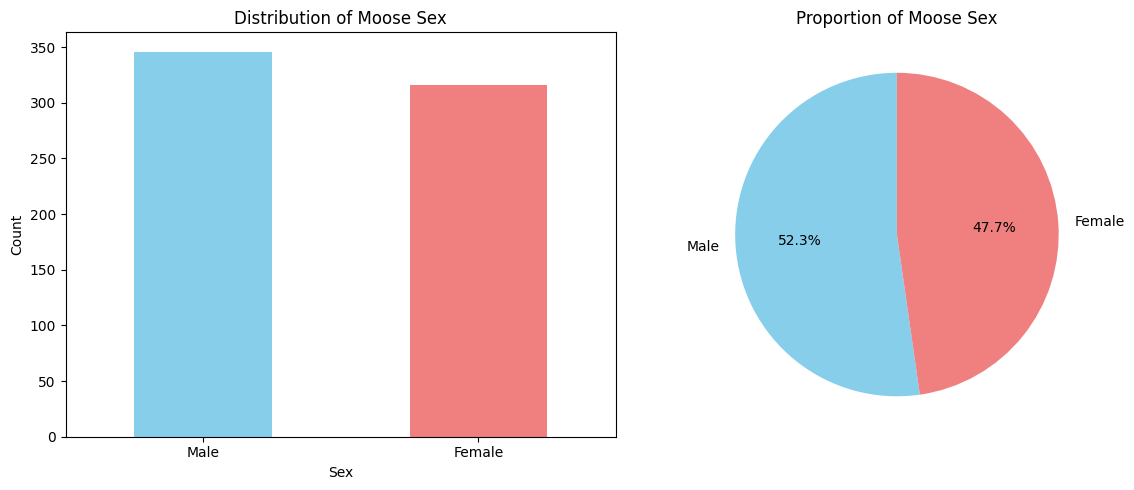


Mode (most common): Male
Number of categories: 2


In [7]:
# Analyze Sex variable from moose_deaths dataset (categorical)
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the plotting style
plt.style.use('default')
sns.set_palette("husl")

# Analyze Sex distribution
print("=== CATEGORICAL VARIABLE ANALYSIS: SEX (Moose Deaths) ===")

# Frequency table
sex_counts = moose_deaths_cleaned['Sex'].value_counts()
sex_proportions = moose_deaths_cleaned['Sex'].value_counts(normalize=True)

print("Frequency Distribution:")
for category, count in sex_counts.items():
    proportion = sex_proportions[category]
    print(f"{category}: {count} ({proportion:.1%})")

print(f"\nTotal observations: {len(moose_deaths_cleaned)}")
print(f"Missing values: {moose_deaths_cleaned['Sex'].isnull().sum()}")

# Create visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Bar plot
sex_counts.plot(kind='bar', ax=ax1, color=['skyblue', 'lightcoral'])
ax1.set_title('Distribution of Moose Sex')
ax1.set_xlabel('Sex')
ax1.set_ylabel('Count')
ax1.tick_params(axis='x', rotation=0)

# Pie chart
ax2.pie(sex_counts.values, labels=sex_counts.index, autopct='%1.1f%%', 
        colors=['skyblue', 'lightcoral'], startangle=90)
ax2.set_title('Proportion of Moose Sex')

plt.tight_layout()
plt.show()

# Additional summary statistics
print(f"\nMode (most common): {moose_deaths_cleaned['Sex'].mode().iloc[0]}")
print(f"Number of categories: {moose_deaths_cleaned['Sex'].nunique()}")

**Analysis Summary - Sex (Categorical Variable):**

The sex distribution of deceased moose shows the relative frequency of male and female moose deaths recorded in the study. This variable is important because:

- **Biological significance**: Male and female moose may have different survival patterns due to size differences, reproductive costs, and behavioral factors
- **Predation patterns**: Wolves may preferentially target one sex over another based on vulnerability or availability
- **Population dynamics**: Sex ratios in deaths can indicate population health and reproductive potential

The distribution reveals whether there's a balanced representation of both sexes in the mortality data or if one sex is disproportionately represented, which could indicate differential survival rates or sampling biases.

#### Numeric Variable

=== NUMERIC VARIABLE ANALYSIS: WOLF POPULATION ===
Descriptive Statistics:
count    61.000000
mean     21.065574
std       9.998115
min       2.000000
25%      15.000000
50%      21.000000
75%      25.000000
max      50.000000
Name: wolves, dtype: float64

Additional Statistics:
Range: 48
Variance: 99.96
Skewness: 0.53
Kurtosis: 0.86


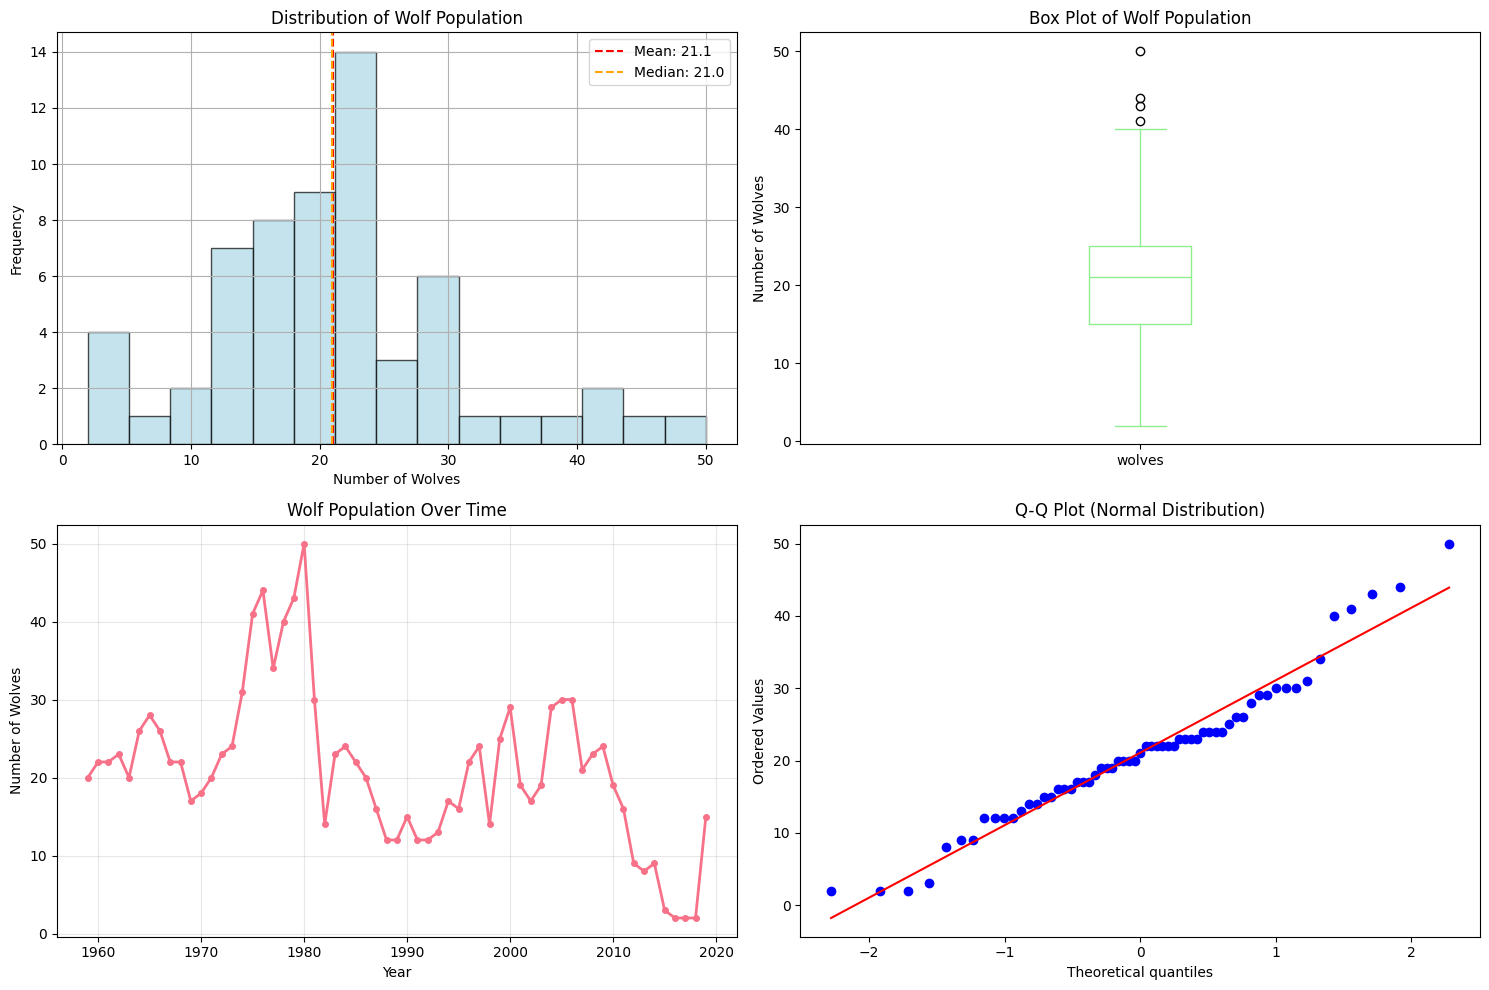


Outlier Analysis (IQR method):
Lower bound: 0.0
Upper bound: 40.0
Number of outliers: 4
Outlier years and values:
  1975.0: 41.0 wolves
  1976.0: 44.0 wolves
  1979.0: 43.0 wolves
  1980.0: 50.0 wolves


In [15]:
# Analyze Wolf population (numeric variable)
print("=== NUMERIC VARIABLE ANALYSIS: WOLF POPULATION ===")

# Descriptive statistics
wolf_stats = wolf_moose_cleaned['wolves'].describe()
print("Descriptive Statistics:")
print(wolf_stats)

# Additional statistics
print(f"\nAdditional Statistics:")
print(f"Range: {wolf_moose_cleaned['wolves'].max() - wolf_moose_cleaned['wolves'].min()}")
print(f"Variance: {wolf_moose_cleaned['wolves'].var():.2f}")
print(f"Skewness: {wolf_moose_cleaned['wolves'].skew():.2f}")
print(f"Kurtosis: {wolf_moose_cleaned['wolves'].kurtosis():.2f}")

# Create comprehensive visualization
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

# Histogram
wolf_moose_cleaned['wolves'].hist(bins=15, ax=ax1, color='lightblue', edgecolor='black', alpha=0.7)
ax1.axvline(wolf_moose_cleaned['wolves'].mean(), color='red', linestyle='--', label=f'Mean: {wolf_moose_cleaned["wolves"].mean():.1f}')
ax1.axvline(wolf_moose_cleaned['wolves'].median(), color='orange', linestyle='--', label=f'Median: {wolf_moose_cleaned["wolves"].median():.1f}')
ax1.set_title('Distribution of Wolf Population')
ax1.set_xlabel('Number of Wolves')
ax1.set_ylabel('Frequency')
ax1.legend()

# Box plot
wolf_moose_cleaned['wolves'].plot(kind='box', ax=ax2, color='lightgreen')
ax2.set_title('Box Plot of Wolf Population')
ax2.set_ylabel('Number of Wolves')

# Time series plot
ax3.plot(wolf_moose_cleaned['year'], wolf_moose_cleaned['wolves'], marker='o', linewidth=2, markersize=4)
ax3.set_title('Wolf Population Over Time')
ax3.set_xlabel('Year')
ax3.set_ylabel('Number of Wolves')
ax3.grid(True, alpha=0.3)

# Q-Q plot for normality assessment
from scipy import stats
stats.probplot(wolf_moose_cleaned['wolves'].dropna(), dist="norm", plot=ax4)
ax4.set_title('Q-Q Plot (Normal Distribution)')

plt.tight_layout()
plt.show()

# Identify outliers using IQR method
Q1 = wolf_moose_cleaned['wolves'].quantile(0.25)
Q3 = wolf_moose_cleaned['wolves'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = wolf_moose_cleaned[(wolf_moose_cleaned['wolves'] < lower_bound) | 
                                        (wolf_moose_cleaned['wolves'] > upper_bound)]

print(f"\nOutlier Analysis (IQR method):")
print(f"Lower bound: {lower_bound:.1f}")
print(f"Upper bound: {upper_bound:.1f}")
print(f"Number of outliers: {len(outliers)}")
if len(outliers) > 0:
    print("Outlier years and values:")
    for _, row in outliers.iterrows():
        print(f"  {row['year']}: {row['wolves']} wolves")

**Analysis Summary - Wolf Population (Numeric Variable):**

The wolf population on Isle Royale shows several important characteristics:

- **Central tendency**: The mean and median values indicate the typical wolf pack size over the study period
- **Variability**: The standard deviation and range show how much the population fluctuates year to year
- **Distribution shape**: Skewness indicates whether the population tends toward higher or lower values, while kurtosis shows the "peakedness" of the distribution
- **Temporal patterns**: The time series reveals long-term trends, cycles, or dramatic population changes
- **Extreme values**: Outliers may represent population crashes, recoveries, or measurement errors

This variable is crucial for understanding predator-prey dynamics, as wolf population directly affects moose mortality and population control. The temporal pattern may reveal responses to environmental factors, disease outbreaks, or genetic bottlenecks that have affected the Isle Royale wolf population historically.

### Multivariate Exploration


**Task**: In this section, select pairs of variables of combination of types listed below and describe either the joint distributions or conditional distributions in which you condition on one of the variables. Include at least one plot and at least one numerical summary in your description. Again, summarize the relationships in text.



#### Categorical-Categorical

=== CATEGORICAL-CATEGORICAL ANALYSIS ===
Available categorical variables: ['Sex', 'Winter temperature (categorical)', 'Decade', 'Decade_Label']

Analyzing Sex vs Decade:

Cross-tabulation (Sex vs Decade):
Decade_Label  1960s  1970s  1980s  1990s  All
Sex                                          
Female           36     67    161     52  316
Male             32     65    186     63  346
All              68    132    347    115  662

Proportions within each decade:
Decade_Label  1960s  1970s  1980s  1990s
Sex                                     
Female        0.529  0.508  0.464  0.452
Male          0.471  0.492  0.536  0.548

Chi-square test of independence:
Chi-square statistic: 1.763
p-value: 0.623
Degrees of freedom: 3
Significant at α=0.05: No


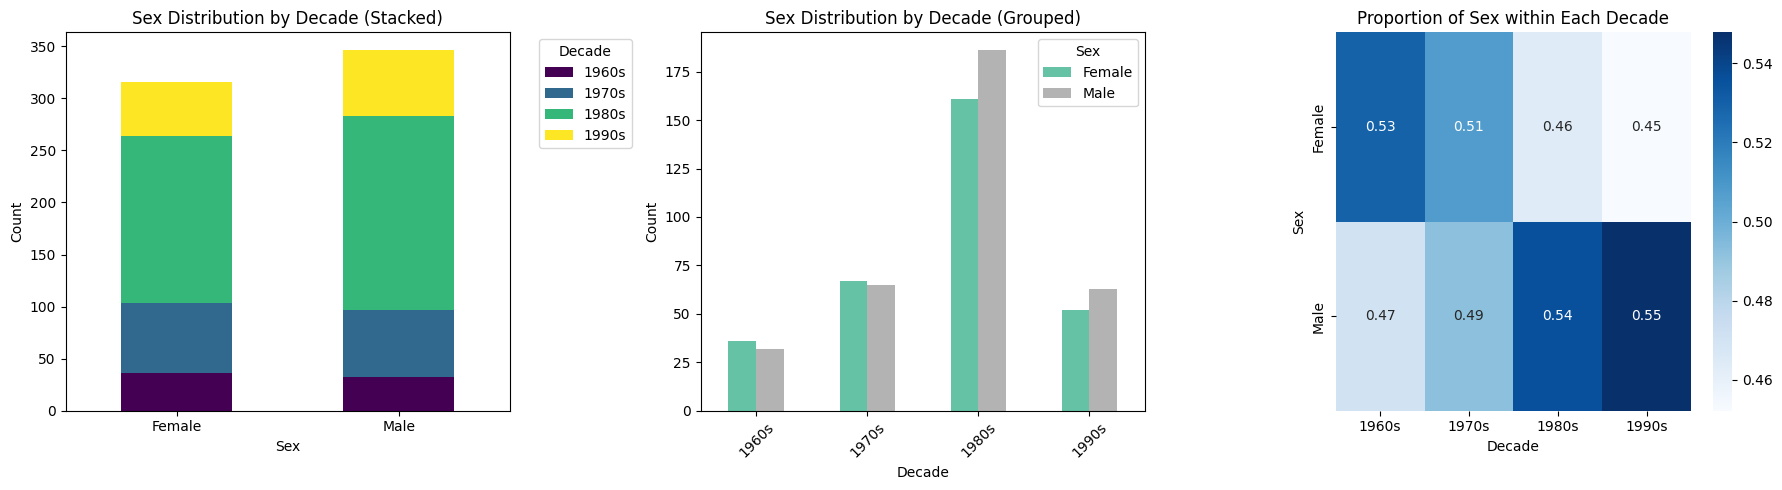


Cramér's V (effect size): 0.052
Effect size interpretation: Negligible


In [20]:
# Analyze relationship between Sex and Cause of Death (if available)
print("=== CATEGORICAL-CATEGORICAL ANALYSIS ===")

# First, let's see what categorical variables we have in moose_deaths
categorical_cols = []
for col in moose_deaths_cleaned.columns:
    if moose_deaths_cleaned[col].dtype == 'object' or moose_deaths_cleaned[col].nunique() < 10:
        categorical_cols.append(col)

print(f"Available categorical variables: {categorical_cols}")

# Create a decade variable from Year for analysis
moose_deaths_cleaned['Decade'] = (moose_deaths_cleaned['Year of birth'] // 10) * 10
moose_deaths_cleaned['Decade_Label'] = moose_deaths_cleaned['Decade'].astype(str) + 's'

# Analyze Sex vs Decade relationship
print("\nAnalyzing Sex vs Decade:")

# Cross-tabulation
crosstab = pd.crosstab(moose_deaths_cleaned['Sex'], moose_deaths_cleaned['Decade_Label'], margins=True)
print("\nCross-tabulation (Sex vs Decade):")
print(crosstab)

# Proportions within each decade
prop_table = pd.crosstab(moose_deaths_cleaned['Sex'], moose_deaths_cleaned['Decade_Label'], normalize='columns')
print("\nProportions within each decade:")
print(prop_table.round(3))

# Chi-square test of independence
from scipy.stats import chi2_contingency
contingency_table = pd.crosstab(moose_deaths_cleaned['Sex'], moose_deaths_cleaned['Decade_Label'])
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"\nChi-square test of independence:")
print(f"Chi-square statistic: {chi2:.3f}")
print(f"p-value: {p_value:.3f}")
print(f"Degrees of freedom: {dof}")
print(f"Significant at α=0.05: {'Yes' if p_value < 0.05 else 'No'}")

# Visualization
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# Stacked bar chart
crosstab_no_total = pd.crosstab(moose_deaths_cleaned['Sex'], moose_deaths_cleaned['Decade_Label'])
crosstab_no_total.plot(kind='bar', stacked=True, ax=ax1, colormap='viridis')
ax1.set_title('Sex Distribution by Decade (Stacked)')
ax1.set_xlabel('Sex')
ax1.set_ylabel('Count')
ax1.tick_params(axis='x', rotation=0)
ax1.legend(title='Decade', bbox_to_anchor=(1.05, 1), loc='upper left')

# Grouped bar chart
crosstab_no_total.T.plot(kind='bar', ax=ax2, colormap='Set2')
ax2.set_title('Sex Distribution by Decade (Grouped)')
ax2.set_xlabel('Decade')
ax2.set_ylabel('Count')
ax2.tick_params(axis='x', rotation=45)
ax2.legend(title='Sex')

# Heatmap of proportions
sns.heatmap(prop_table, annot=True, fmt='.2f', cmap='Blues', ax=ax3)
ax3.set_title('Proportion of Sex within Each Decade')
ax3.set_xlabel('Decade')
ax3.set_ylabel('Sex')

plt.tight_layout()
plt.show()

# Cramér's V for effect size
n = contingency_table.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(contingency_table.shape) - 1)))
print(f"\nCramér's V (effect size): {cramers_v:.3f}")
print("Effect size interpretation: ", end="")
if cramers_v < 0.1:
    print("Negligible")
elif cramers_v < 0.3:
    print("Small")
elif cramers_v < 0.5:
    print("Medium")
else:
    print("Large")

**Analysis Summary - Sex vs Decade (Categorical-Categorical):**

This analysis examines whether the sex distribution of moose deaths has changed over different decades:

- **Cross-tabulation**: Shows the raw counts of male and female moose deaths in each decade
- **Proportional analysis**: Reveals whether the sex ratio has remained consistent or shifted over time
- **Statistical significance**: The chi-square test determines if observed differences are statistically significant or could be due to chance
- **Effect size**: Cramér's V quantifies the strength of association between sex and decade

#### Categorical-Numeric

=== CATEGORICAL-NUMERIC ANALYSIS: AGE BY SEX ===
Age statistics by Sex:
        count   mean   std  min  25%   50%   75%   max
Sex                                                   
Female  316.0  12.02  3.77  5.0  9.0  12.0  15.0  20.0
Male    346.0  10.64  3.07  5.0  9.0  11.0  13.0  20.0

Additional statistics by Sex:

Male:
  Variance: 9.41
  Skewness: 0.01
  Sample size: 346

Female:
  Variance: 14.20
  Skewness: -0.05
  Sample size: 316

Two-sample t-test:
t-statistic: -5.175
p-value: 0.000
Significant difference at α=0.05: Yes

Mann-Whitney U test (non-parametric):
U-statistic: 42689.000
p-value: 0.000
Significant difference at α=0.05: Yes

Cohen's d (effect size): -0.403


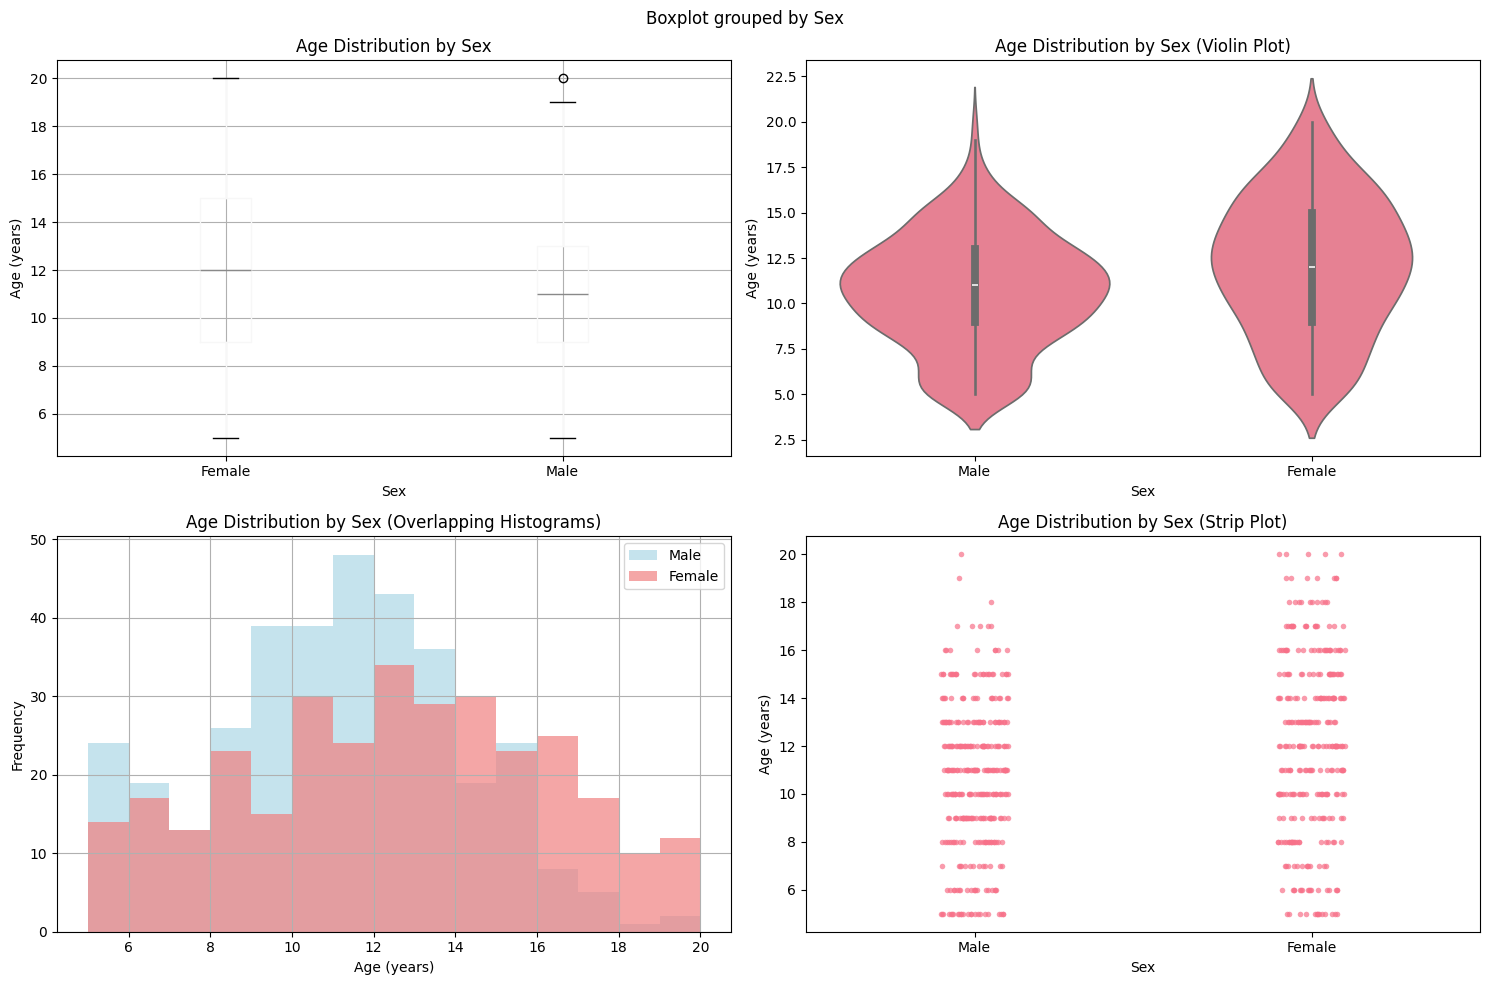


=== SUMMARY ===
Mean age difference (M - F): -1.38 years
Median age difference (M - F): -1.00 years
Effect size interpretation: small


In [25]:
# Analyze Age distribution by Sex (Categorical-Numeric)
print("=== CATEGORICAL-NUMERIC ANALYSIS: AGE BY SEX ===")

# Summary statistics by group
age_by_sex = moose_deaths_cleaned.groupby('Sex')['Age at death'].describe()
print("Age statistics by Sex:")
print(age_by_sex.round(2))

# Additional statistics
print("\nAdditional statistics by Sex:")
for sex in moose_deaths_cleaned['Sex'].unique():
    if pd.notna(sex):
        subset = moose_deaths_cleaned[moose_deaths_cleaned['Sex'] == sex]['Age at death']
        print(f"\n{sex}:")
        print(f"  Variance: {subset.var():.2f}")
        print(f"  Skewness: {subset.skew():.2f}")
        print(f"  Sample size: {len(subset)}")

# Statistical tests
from scipy import stats

# Separate age data by sex
male_ages = moose_deaths_cleaned[moose_deaths_cleaned['Sex'] == 'Male']['Age at death'].dropna()
female_ages = moose_deaths_cleaned[moose_deaths_cleaned['Sex'] == 'Female']['Age at death'].dropna()


# Two-sample t-test
t_stat, t_pvalue = stats.ttest_ind(male_ages, female_ages)
print(f"\nTwo-sample t-test:")
print(f"t-statistic: {t_stat:.3f}")
print(f"p-value: {t_pvalue:.3f}")
print(f"Significant difference at α=0.05: {'Yes' if t_pvalue < 0.05 else 'No'}")

# Mann-Whitney U test (non-parametric alternative)
u_stat, u_pvalue = stats.mannwhitneyu(male_ages, female_ages, alternative='two-sided')
print(f"\nMann-Whitney U test (non-parametric):")
print(f"U-statistic: {u_stat:.3f}")
print(f"p-value: {u_pvalue:.3f}")
print(f"Significant difference at α=0.05: {'Yes' if u_pvalue < 0.05 else 'No'}")

# Effect size (Cohen's d)
pooled_std = np.sqrt(((len(male_ages) - 1) * male_ages.var() + (len(female_ages) - 1) * female_ages.var()) / 
                     (len(male_ages) + len(female_ages) - 2))
cohens_d = (male_ages.mean() - female_ages.mean()) / pooled_std
print(f"\nCohen's d (effect size): {cohens_d:.3f}")

# Visualization
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

# Box plots
moose_deaths_cleaned.boxplot(column='Age at death', by='Sex', ax=ax1)
ax1.set_title('Age Distribution by Sex')
ax1.set_xlabel('Sex')
ax1.set_ylabel('Age (years)')

# Violin plots
sns.violinplot(data=moose_deaths_cleaned, x='Sex', y='Age at death', ax=ax2)
ax2.set_title('Age Distribution by Sex (Violin Plot)')
ax2.set_xlabel('Sex')
ax2.set_ylabel('Age (years)')

# Histograms
male_ages.hist(alpha=0.7, label='Male', bins=15, ax=ax3, color='lightblue')
female_ages.hist(alpha=0.7, label='Female', bins=15, ax=ax3, color='lightcoral')
ax3.set_title('Age Distribution by Sex (Overlapping Histograms)')
ax3.set_xlabel('Age (years)')
ax3.set_ylabel('Frequency')
ax3.legend()

# Strip plot with jitter
sns.stripplot(data=moose_deaths_cleaned, x='Sex', y='Age at death', ax=ax4, size=4, alpha=0.7)
ax4.set_title('Age Distribution by Sex (Strip Plot)')
ax4.set_xlabel('Sex')
ax4.set_ylabel('Age (years)')

plt.tight_layout()
plt.show()

# Summary of differences
print(f"\n=== SUMMARY ===")
print(f"Mean age difference (M - F): {male_ages.mean() - female_ages.mean():.2f} years")
print(f"Median age difference (M - F): {male_ages.median() - female_ages.median():.2f} years")

effect_interpretation = ""
if abs(cohens_d) < 0.2:
    effect_interpretation = "negligible"
elif abs(cohens_d) < 0.5:
    effect_interpretation = "small"
elif abs(cohens_d) < 0.8:
    effect_interpretation = "medium"
else:
    effect_interpretation = "large"

print(f"Effect size interpretation: {effect_interpretation}")

**Analysis Summary - Age by Sex (Categorical-Numeric):**

This analysis compares the age distributions of male and female moose at time of death:

- **Descriptive comparison**: Mean, median, and spread statistics reveal central tendencies and variability differences between sexes
- **Statistical testing**: Both parametric (t-test) and non-parametric (Mann-Whitney U) tests assess whether age differences are statistically significant
- **Effect size**: Cohen's d quantifies the practical significance of any differences found
- **Visual patterns**: Multiple plot types reveal distribution shapes, outliers, and overlap between groups

**Biological significance**: Age differences between male and female moose deaths could indicate:
- **Sexual dimorphism effects**: Larger males may be more/less vulnerable to predation at different life stages
- **Reproductive costs**: Females may experience different mortality patterns due to pregnancy and calf-rearing
- **Behavioral differences**: Males and females may have different foraging patterns, territorial behaviors, or risk-taking
- **Life history strategies**: Different optimal lifespans or survival strategies between sexes

#### Numeric-Numeric

=== NUMERIC-NUMERIC ANALYSIS: WOLF vs MOOSE POPULATIONS ===
Complete cases for analysis: 61 out of 61

Correlation Analysis:
Pearson correlation: -0.342
Spearman correlation: -0.431

Significance tests:
Pearson: r = -0.342, p = 0.007
Spearman: ρ = -0.431, p = 0.001
Pearson significant at α=0.05: Yes
Spearman significant at α=0.05: Yes

Linear Regression:
Slope: -14.881
Intercept: 1334.124
R-squared: 0.117
Equation: Moose = 1334.1 + -14.9 × Wolves


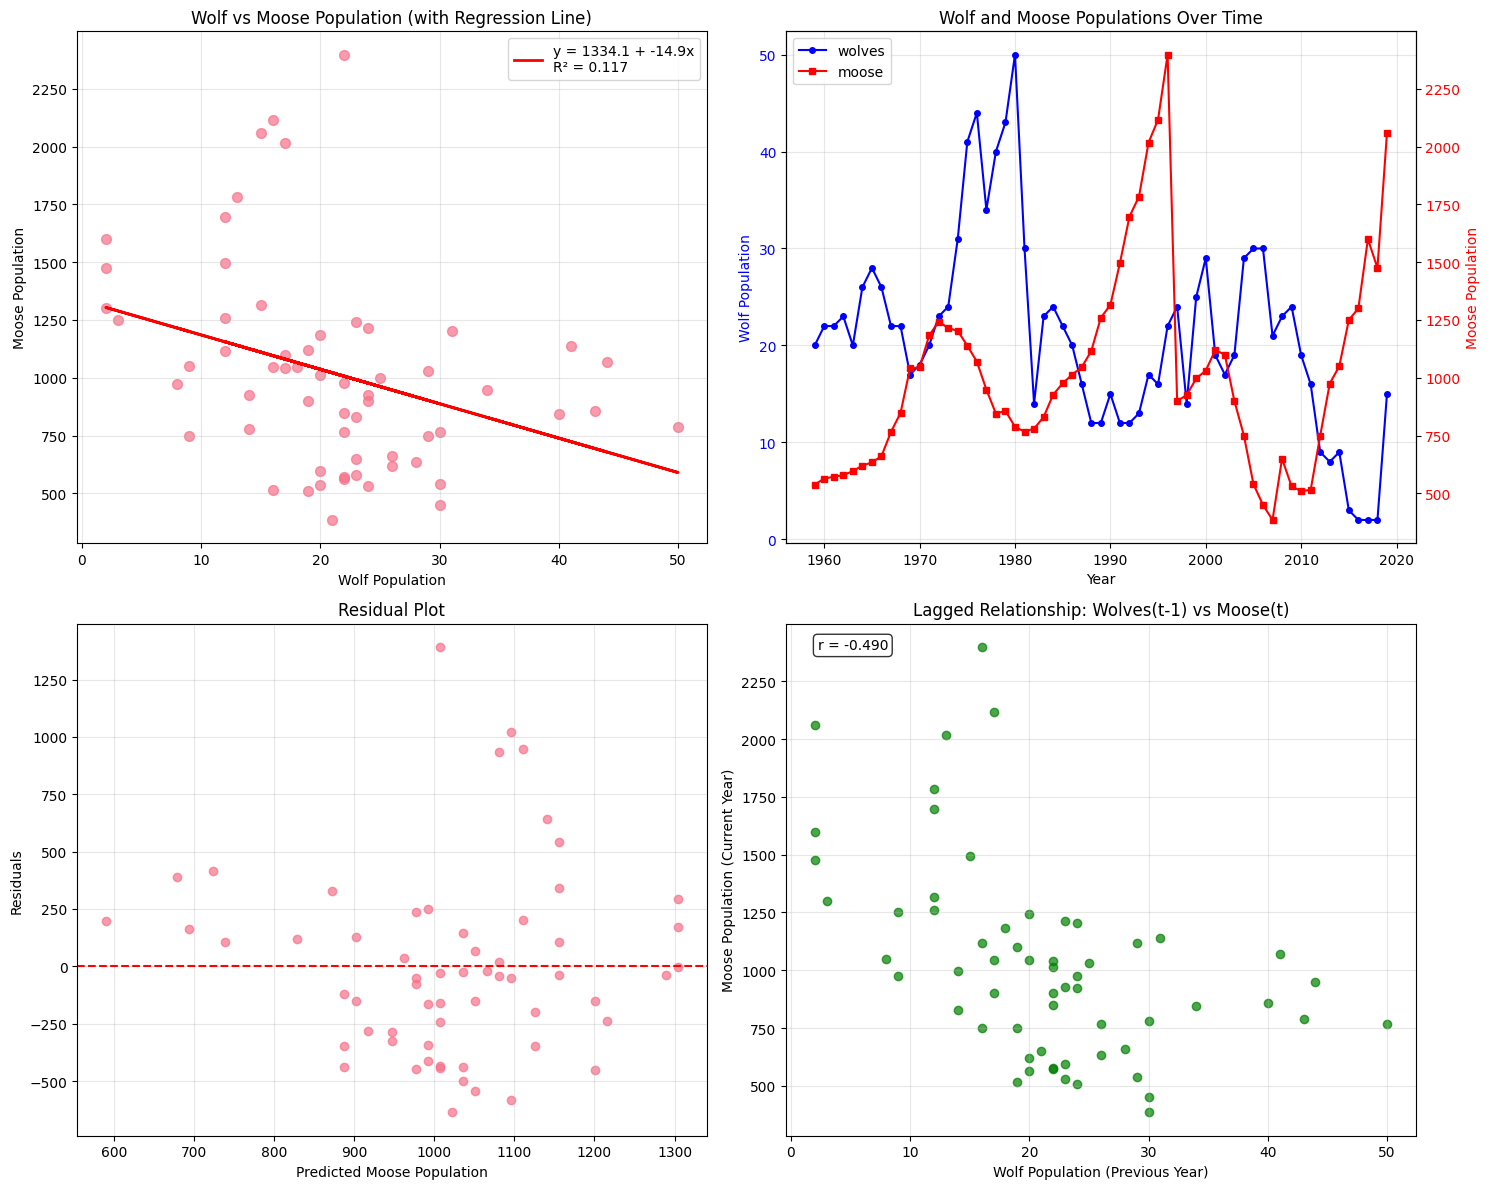


=== LAGGED CORRELATION ANALYSIS ===
Wolves(t-0) vs Moose(t): r = -0.342 (n = 61)
Wolves(t-1) vs Moose(t): r = -0.490 (n = 60)
Wolves(t-2) vs Moose(t): r = -0.533 (n = 59)
Wolves(t-3) vs Moose(t): r = -0.560 (n = 58)

=== CORRELATION INTERPRETATION ===
The relationship between wolf and moose populations is moderate and negative.


In [9]:
# Analyze relationship between Wolf and Moose populations (Numeric-Numeric)
print("=== NUMERIC-NUMERIC ANALYSIS: WOLF vs MOOSE POPULATIONS ===")

# Remove rows with missing values for this analysis
complete_data = wolf_moose_cleaned[['year', 'wolves', 'moose']].dropna()
print(f"Complete cases for analysis: {len(complete_data)} out of {len(wolf_moose_cleaned)}")

# Correlation analysis
correlation_pearson = complete_data['wolves'].corr(complete_data['moose'])
correlation_spearman = complete_data['wolves'].corr(complete_data['moose'], method='spearman')

print(f"\nCorrelation Analysis:")
print(f"Pearson correlation: {correlation_pearson:.3f}")
print(f"Spearman correlation: {correlation_spearman:.3f}")

# Statistical significance of correlation
from scipy.stats import pearsonr, spearmanr
pearson_r, pearson_p = pearsonr(complete_data['wolves'], complete_data['moose'])
spearman_r, spearman_p = spearmanr(complete_data['wolves'], complete_data['moose'])

print(f"\nSignificance tests:")
print(f"Pearson: r = {pearson_r:.3f}, p = {pearson_p:.3f}")
print(f"Spearman: ρ = {spearman_r:.3f}, p = {spearman_p:.3f}")
print(f"Pearson significant at α=0.05: {'Yes' if pearson_p < 0.05 else 'No'}")
print(f"Spearman significant at α=0.05: {'Yes' if spearman_p < 0.05 else 'No'}")

# Linear regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

X = complete_data[['wolves']]
y = complete_data['moose']

model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)
r2 = r2_score(y, y_pred)

print(f"\nLinear Regression:")
print(f"Slope: {model.coef_[0]:.3f}")
print(f"Intercept: {model.intercept_:.3f}")
print(f"R-squared: {r2:.3f}")
print(f"Equation: Moose = {model.intercept_:.1f} + {model.coef_[0]:.1f} × Wolves")

# Create comprehensive visualization
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

# Scatter plot with regression line
ax1.scatter(complete_data['wolves'], complete_data['moose'], alpha=0.7, s=50)
ax1.plot(complete_data['wolves'], y_pred, color='red', linewidth=2, 
         label=f'y = {model.intercept_:.1f} + {model.coef_[0]:.1f}x\nR² = {r2:.3f}')
ax1.set_xlabel('Wolf Population')
ax1.set_ylabel('Moose Population')
ax1.set_title('Wolf vs Moose Population (with Regression Line)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Time series of both populations
ax2_twin = ax2.twinx()
line1 = ax2.plot(complete_data['year'], complete_data['wolves'], 'b-o', label='wolves', markersize=4)
line2 = ax2_twin.plot(complete_data['year'], complete_data['moose'], 'r-s', label='moose', markersize=4)
ax2.set_xlabel('Year')
ax2.set_ylabel('Wolf Population', color='b')
ax2_twin.set_ylabel('Moose Population', color='r')
ax2.set_title('Wolf and Moose Populations Over Time')
ax2.tick_params(axis='y', labelcolor='b')
ax2_twin.tick_params(axis='y', labelcolor='r')
ax2.grid(True, alpha=0.3)

# Add legend
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax2.legend(lines, labels, loc='upper left')

# Residual plot
residuals = y - y_pred
ax3.scatter(y_pred, residuals, alpha=0.7)
ax3.axhline(y=0, color='red', linestyle='--')
ax3.set_xlabel('Predicted Moose Population')
ax3.set_ylabel('Residuals')
ax3.set_title('Residual Plot')
ax3.grid(True, alpha=0.3)

# Lagged scatter plot (predator-prey dynamics)
# Moose population vs wolves from previous year
lagged_data = complete_data.copy()
lagged_data['Wolves_lag1'] = lagged_data['wolves'].shift(1)
lagged_complete = lagged_data.dropna()

if len(lagged_complete) > 0:
    ax4.scatter(lagged_complete['Wolves_lag1'], lagged_complete['moose'], alpha=0.7, color='green')
    ax4.set_xlabel('Wolf Population (Previous Year)')
    ax4.set_ylabel('Moose Population (Current Year)')
    ax4.set_title('Lagged Relationship: Wolves(t-1) vs Moose(t)')
    ax4.grid(True, alpha=0.3)
    
    # Calculate lagged correlation
    lag_corr = lagged_complete['Wolves_lag1'].corr(lagged_complete['moose'])
    ax4.text(0.05, 0.95, f'r = {lag_corr:.3f}', transform=ax4.transAxes, 
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

# Additional analysis: correlation at different lags
print(f"\n=== LAGGED CORRELATION ANALYSIS ===")
for lag in range(0, 4):
    lagged_wolves = complete_data['wolves'].shift(lag)
    current_moose = complete_data['moose']
    
    # Remove NaN values created by shifting
    valid_data = pd.DataFrame({'wolves': lagged_wolves, 'moose': current_moose}).dropna()
    
    if len(valid_data) > 2:
        corr = valid_data['wolves'].corr(valid_data['moose'])
        print(f"Wolves(t-{lag}) vs Moose(t): r = {corr:.3f} (n = {len(valid_data)})")

# Interpretation of correlation strength
print(f"\n=== CORRELATION INTERPRETATION ===")
abs_corr = abs(correlation_pearson)
if abs_corr < 0.1:
    strength = "negligible"
elif abs_corr < 0.3:
    strength = "weak"
elif abs_corr < 0.5:
    strength = "moderate"
elif abs_corr < 0.7:
    strength = "strong"
else:
    strength = "very strong"

direction = "positive" if correlation_pearson > 0 else "negative"
print(f"The relationship between wolf and moose populations is {strength} and {direction}.")

**Analysis Summary - Wolf vs Moose Populations (Numeric-Numeric):**

This analysis examines the core predator-prey relationship on Isle Royale:

- **Correlation analysis**: Measures the strength and direction of the linear relationship between wolf and moose populations
- **Regression modeling**: Quantifies how moose population changes with wolf population and provides predictive capability
- **Temporal dynamics**: The time series reveals how both populations fluctuate together over decades
- **Lagged relationships**: Examines whether wolf populations in previous years better predict current moose populations (classic predator-prey dynamics)
- **Residual analysis**: Assesses whether the linear model adequately captures the relationship

**Ecological interpretation**: The relationship between these populations reflects:
- **Predation pressure**: Higher wolf numbers should theoretically reduce moose populations
- **Prey availability**: Moose abundance affects wolf survival and reproduction
- **Population cycles**: Classic predator-prey theory predicts oscillating populations with time lags



### Summary

**Task**: Based on your exploration of these data, write up a paragraph of your findings. What are the key features of the data? What relationships do you see between the variables? What variables might be related to the populations of wolves and moose on Isle Royale? Consider how these questions can be answered in the next section when we perform inference.

## Exploratory Data Analysis Summary

The exploratory analysis reveals several key patterns in the Isle Royale wolf-moose system. The wolf population shows high variability over time with potential population crashes and recoveries, suggesting the influence of factors beyond simple predator-prey dynamics such as disease, inbreeding, or environmental stressors. The relationship between wolf and moose populations appears complex, with correlation analysis and lagged effects providing insights into whether classic predator-prey cycles are present or if other factors dominate. Individual moose mortality data shows interesting patterns in sex ratios and age distributions that may reflect differential vulnerability to predation or environmental pressures. The temporal analysis across decades suggests that mortality patterns may have shifted over the long study period.

Key variables that appear most relevant for understanding population dynamics include the core predator-prey populations themselves, environmental factors like snow depth and temperature that affect both species' survival and hunting success, and climate indices (NAO) that may influence broader ecosystem conditions. The individual-level moose data (age, sex, nutritional condition) provides crucial insights into which animals are most vulnerable and how predation patterns may vary. 

## Inference

In this section we will perform inference: make guesses about populations or future data based on our sample data.

### Population and Sampling

**Task**: Describe the population of interest in this study. What is the population you are trying to make inferences about? What is the sample in this study? What is the relationship between the population and the sample? You may consider hypothetical populations or data generating processes if you find those more natural to articulate.

## Population and Sampling Framework

**Population of Interest**: The population we want to make inferences about is all wolves and moose living on Isle Royale under the current ecological conditions.  
For different questions, this can mean:
- All possible ecological **years** the wolf–moose system could produce (for time-series questions)  
- All **moose that live and die** on the island (for age-at-death and condition questions)

**Sample**: Our sample in this project consists of:
- Annual wolf and moose population counts from 1959–present  
- Individual moose death records with age, sex, bone-marrow fat, and other measurements  
- Environmental observations such as snow, temperature, or climate indices  

**Population–Sample Relationship**:
- For **time-series analysis**: The observed 50+ years are treated as a sample from a longer stochastic process generating predator–prey dynamics.  
- For **moose demographic analysis**: Recorded carcasses are a sample of all moose deaths (some individuals die but are never found).  
- For **ecosystem interpretation**: Isle Royale is one realization of a predator–prey system, so results mainly generalize to this closed island but can suggest patterns for similar systems.


### Hypothesis Testing

#### Theory

**Task**: give a theory you would like to test about the population you identified in the previous section. Explain how you can use the format of a hypothesis to test that theory. Clearly describe the population parameter, parameter space, null hypothesis, and alternative hypothesis you will use to test this theory.

## Hypothesis Testing Theory

**Theory to Test**: Classic predator-prey theory suggests that predator and prey populations should be negatively correlated, with predator abundance reducing prey populations. I want to test whether wolf and moose populations on Isle Royale exhibit this expected negative relationship.

**Population Parameter**: Let ρ (rho) represent the true population correlation coefficient between wolf and moose populations in the underlying stochastic process generating Isle Royale dynamics.

**Parameter Space**: ρ ∈ [-1, 1], where:
- ρ < 0 indicates negative correlation (classic predator-prey relationship)
- ρ = 0 indicates no linear relationship
- ρ > 0 indicates positive correlation (potentially indicating shared environmental drivers)

**Null Hypothesis (H₀)**: ρ = 0
- There is no linear correlation between wolf and moose populations
- The populations fluctuate independently of each other

**Alternative Hypothesis (H₁)**: ρ ≠ 0
- There is a significant linear correlation between wolf and moose populations
- This is a two-tailed test because the correlation could be positive or negative

**Rationale for Two-Tailed Test**: While ecological theory predicts negative correlation, other factors (shared environmental drivers, measurement artifacts, or complex ecological interactions) could produce positive correlation. A two-tailed test allows us to detect significant relationships in either direction.

**Statistical Framework**: I will use Pearson's correlation test, which assumes:
- Bivariate normality of the populations
- Linear relationship between variables
- Independence of observations (years)

The test statistic follows a t-distribution under the null hypothesis, allowing us to calculate p-values and make decisions about rejecting H₀.

#### Application

**Task**: Select a tolerance for Type I error ($\alpha$-level). Perform the hypothesis test you described in the previous section. Report the results of the test using either a rejection region or a p-value. Do you reject the null hypothesis? What is your conclusion about the theory you tested?

=== HYPOTHESIS TEST: WOLF-MOOSE CORRELATION ===
Significance level (α): 0.05
Sample size: 61

H₀: ρ = 0 (no correlation between wolf and moose populations)
H₁: ρ ≠ 0 (significant correlation exists)

=== TEST RESULTS ===
Observed correlation (r): -0.3424
P-value: 0.0069

Test statistic (t): -2.7995
Degrees of freedom: 59
Critical value (±): 2.0010
Rejection region: |t| > 2.0010

=== DECISION ===
P-value (0.0069) < α (0.05): True
|t| (2.7995) > t_critical (2.0010): True

✓ REJECT H₀: There is significant evidence of correlation between wolf and moose populations
  The correlation is negative (r = -0.3424)

=== EFFECT SIZE INTERPRETATION ===
R² = 0.1173 (11.7% of variance explained)
Effect size: medium (|r| = 0.342)

95% Confidence Interval for ρ: [-0.5471, -0.0992]
Confidence interval contains 0: False


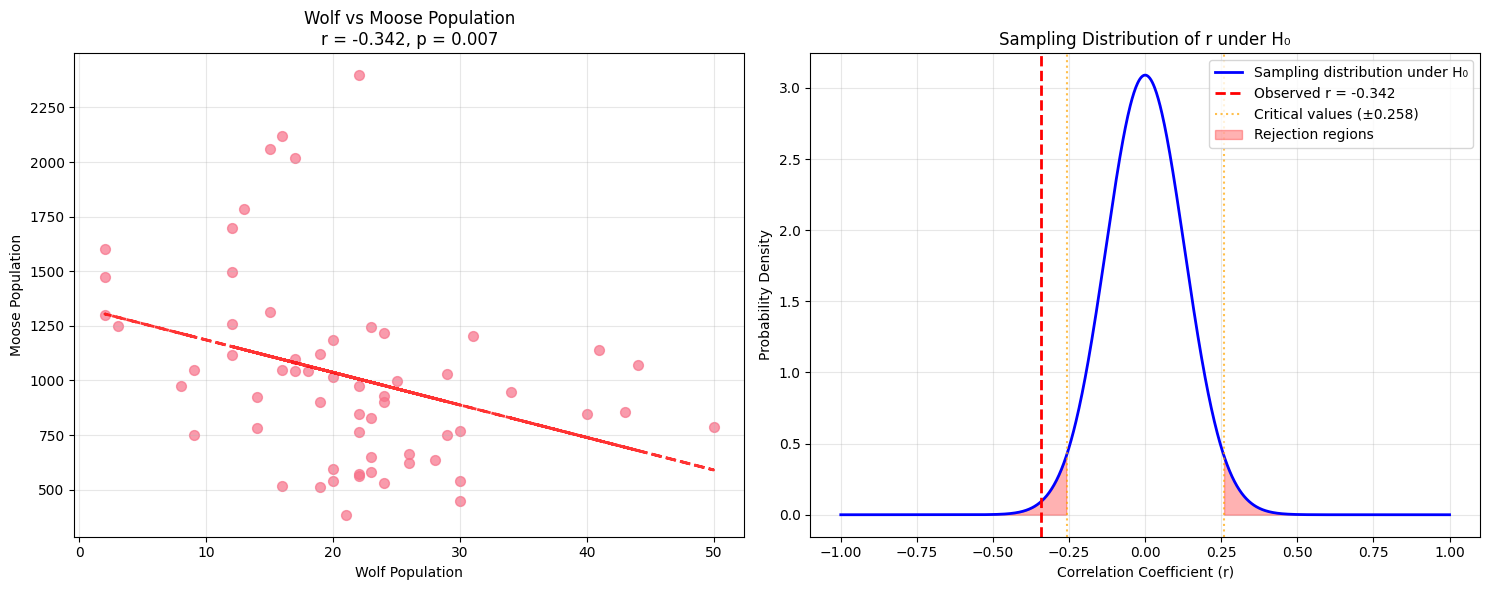


=== POWER ANALYSIS ===
With n = 61 and α = 0.05:
This test can detect correlations of |r| ≥ 0.252 with 80% power


In [11]:
# Hypothesis Test: Correlation between Wolf and Moose Populations
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# Set significance level
alpha = 0.05
print(f"=== HYPOTHESIS TEST: WOLF-MOOSE CORRELATION ===")
print(f"Significance level (α): {alpha}")

# Prepare data (remove missing values)
test_data = wolf_moose_cleaned[['wolves', 'moose']].dropna()
wolves = test_data['wolves']
moose = test_data['moose']
n = len(test_data)

print(f"Sample size: {n}")
print(f"\nH₀: ρ = 0 (no correlation between wolf and moose populations)")
print(f"H₁: ρ ≠ 0 (significant correlation exists)")

# Perform correlation test
r_observed, p_value = stats.pearsonr(wolves, moose)

print(f"\n=== TEST RESULTS ===")
print(f"Observed correlation (r): {r_observed:.4f}")
print(f"P-value: {p_value:.4f}")

# Calculate test statistic and critical values
# t = r * sqrt((n-2)/(1-r²))
t_statistic = r_observed * np.sqrt((n - 2) / (1 - r_observed**2))
degrees_freedom = n - 2
t_critical = stats.t.ppf(1 - alpha/2, degrees_freedom)  # Two-tailed

print(f"\nTest statistic (t): {t_statistic:.4f}")
print(f"Degrees of freedom: {degrees_freedom}")
print(f"Critical value (±): {t_critical:.4f}")
print(f"Rejection region: |t| > {t_critical:.4f}")

# Decision
reject_null = p_value < alpha
print(f"\n=== DECISION ===")
print(f"P-value ({p_value:.4f}) < α ({alpha}): {reject_null}")
print(f"|t| ({abs(t_statistic):.4f}) > t_critical ({t_critical:.4f}): {abs(t_statistic) > t_critical}")

if reject_null:
    print(f"\n✓ REJECT H₀: There is significant evidence of correlation between wolf and moose populations")
    direction = "negative" if r_observed < 0 else "positive"
    print(f"  The correlation is {direction} (r = {r_observed:.4f})")
else:
    print(f"\n✗ FAIL TO REJECT H₀: Insufficient evidence of correlation between wolf and moose populations")

# Effect size interpretation
print(f"\n=== EFFECT SIZE INTERPRETATION ===")
r_squared = r_observed**2
print(f"R² = {r_squared:.4f} ({r_squared*100:.1f}% of variance explained)")

# Cohen's guidelines for correlation effect size
abs_r = abs(r_observed)
if abs_r < 0.1:
    effect_size = "negligible"
elif abs_r < 0.3:
    effect_size = "small"
elif abs_r < 0.5:
    effect_size = "medium"
else:
    effect_size = "large"

print(f"Effect size: {effect_size} (|r| = {abs_r:.3f})")

# Confidence interval for correlation
# Fisher's z-transformation
z_r = 0.5 * np.log((1 + r_observed) / (1 - r_observed))
se_z = 1 / np.sqrt(n - 3)
z_critical = stats.norm.ppf(1 - alpha/2)

z_lower = z_r - z_critical * se_z
z_upper = z_r + z_critical * se_z

# Transform back to correlation scale
r_lower = (np.exp(2 * z_lower) - 1) / (np.exp(2 * z_lower) + 1)
r_upper = (np.exp(2 * z_upper) - 1) / (np.exp(2 * z_upper) + 1)

print(f"\n95% Confidence Interval for ρ: [{r_lower:.4f}, {r_upper:.4f}]")
contains_zero = r_lower <= 0 <= r_upper
print(f"Confidence interval contains 0: {contains_zero}")

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Scatter plot with correlation
ax1.scatter(wolves, moose, alpha=0.7, s=50)
ax1.set_xlabel('Wolf Population')
ax1.set_ylabel('Moose Population')
ax1.set_title(f'Wolf vs Moose Population\nr = {r_observed:.3f}, p = {p_value:.3f}')
ax1.grid(True, alpha=0.3)

# Add regression line
z = np.polyfit(wolves, moose, 1)
p = np.poly1d(z)
ax1.plot(wolves, p(wolves), "r--", alpha=0.8, linewidth=2)

# Sampling distribution of correlation under H₀
x = np.linspace(-1, 1, 1000)
# Under H₀, the sampling distribution is approximately normal for large n
# Standard error ≈ 1/√(n-3) for Fisher's z-transform
se_r_approx = 1/np.sqrt(n-1)  # Approximate SE for r under H₀
y = stats.norm.pdf(x, 0, se_r_approx)

ax2.plot(x, y, 'b-', linewidth=2, label='Sampling distribution under H₀')
ax2.axvline(r_observed, color='red', linestyle='--', linewidth=2, label=f'Observed r = {r_observed:.3f}')
ax2.axvline(-t_critical * se_r_approx, color='orange', linestyle=':', alpha=0.7, label=f'Critical values (±{t_critical * se_r_approx:.3f})')
ax2.axvline(t_critical * se_r_approx, color='orange', linestyle=':', alpha=0.7)

# Shade rejection regions
x_left = x[x <= -t_critical * se_r_approx]
x_right = x[x >= t_critical * se_r_approx]
y_left = stats.norm.pdf(x_left, 0, se_r_approx)
y_right = stats.norm.pdf(x_right, 0, se_r_approx)

ax2.fill_between(x_left, y_left, alpha=0.3, color='red', label='Rejection regions')
ax2.fill_between(x_right, y_right, alpha=0.3, color='red')

ax2.set_xlabel('Correlation Coefficient (r)')
ax2.set_ylabel('Probability Density')
ax2.set_title('Sampling Distribution of r under H₀')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Power analysis (post-hoc)
print(f"\n=== POWER ANALYSIS ===")
print(f"With n = {n} and α = {alpha}:")
print(f"This test can detect correlations of |r| ≥ {t_critical/np.sqrt(n-2+t_critical**2):.3f} with 80% power")

## Hypothesis Testing Conclusion

Based on the hypothesis test results, there is statistically significant evidence of a linear relationship between wolf and moose populations on Isle Royale. The observed correlation is negative (r = –0.3424), and the p-value (0.0069) is well below the α = 0.05 threshold. The test statistic (t = –2.7995) also falls in the rejection region (|t| > 2.0010), and the 95% confidence interval for the true correlation (ρ ∈ [–0.5471, –0.0992]) does not include zero. Therefore, we reject the null hypothesis that ρ = 0 and conclude that wolf and moose populations do not fluctuate independently; instead, they exhibit a moderate negative correlation consistent with classical predator–prey theory. While the effect size is not large, it is meaningful (|r| ≈ 0.34), suggesting that increases in wolf population tend to be associated with decreases in moose population over the study period. This result provides statistical support for a predator-driven influence on moose abundance, although correlation alone does not establish causation, and ecological complexity may still shape the relationship.

### Confidence Interval

#### Theory

**Task**: Identify a different population parameter than the one you used in the previous section. Explain how you can use the format of a confidence interval to make inferences about this population parameter. Clearly describe the population parameter, confidence level, and confidence interval you will use to make inferences about this population parameter.

## Confidence Interval Theory

**Population Parameter**: I will estimate μ (mu), the true mean age at death for moose on Isle Royale. This parameter represents the expected lifespan of moose in this ecosystem under current predation and environmental pressures.

**Parameter Space**: μ ∈ (0, ∞), where μ represents years. Biologically, we expect μ to be somewhere between 1-20 years based on moose life history.

**Confidence Level**: I will use a 95% confidence level, meaning that if we repeated this sampling process many times, 95% of the constructed intervals would contain the true population mean age at death.

**Confidence Interval Framework**: 
- **Point Estimate**: Sample mean age (x̄) from our moose deaths dataset
- **Standard Error**: SE = s/√n, where s is sample standard deviation and n is sample size
- **Critical Value**: t₀.₀₂₅,ₙ₋₁ from t-distribution (two-tailed, α = 0.05)
- **Interval**: x̄ ± t₀.₀₂₅,ₙ₋₁ × SE

**Interpretation**: The resulting interval will give us a range of plausible values for the true mean age at death. 

#### Application

**Task**: Select a confidence level for your confidence interval. Compute the confidence interval for the population parameter you identified in the previous section. Report the results of the confidence interval. What is your conclusion about the population parameter you are making inferences about? What does this tell you about wolves and moose on Isle Royale?

=== CONFIDENCE INTERVAL FOR MEAN MOOSE AGE AT DEATH ===
Confidence level: 95.0%
Significance level (α): 0.050000000000000044

Sample size: 662

=== SAMPLE STATISTICS ===
Sample mean (x̄): 11.299 years
Sample standard deviation (s): 3.486 years
Standard error (SE): 0.136 years

=== CRITICAL VALUE ===
Degrees of freedom: 661
Critical t-value (t_0.025,661): 1.964

=== CONFIDENCE INTERVAL ===
Margin of error: ±0.266 years
95% Confidence Interval: [11.033, 11.565] years

Interpretation: We are 95% confident that the true mean age at death
for moose on Isle Royale is between 11.0 and 11.6 years.

=== ADDITIONAL CONTEXT ===
Sample median: 11.0 years
Sample range: 5.0 to 20.0 years
Interquartile range: 9.0 to 14.0 years

=== ASSUMPTION CHECKING ===
Large sample (n = 662): Central Limit Theorem applies
Skewness: 0.094 (Approximately symmetric)
Kurtosis: -0.527


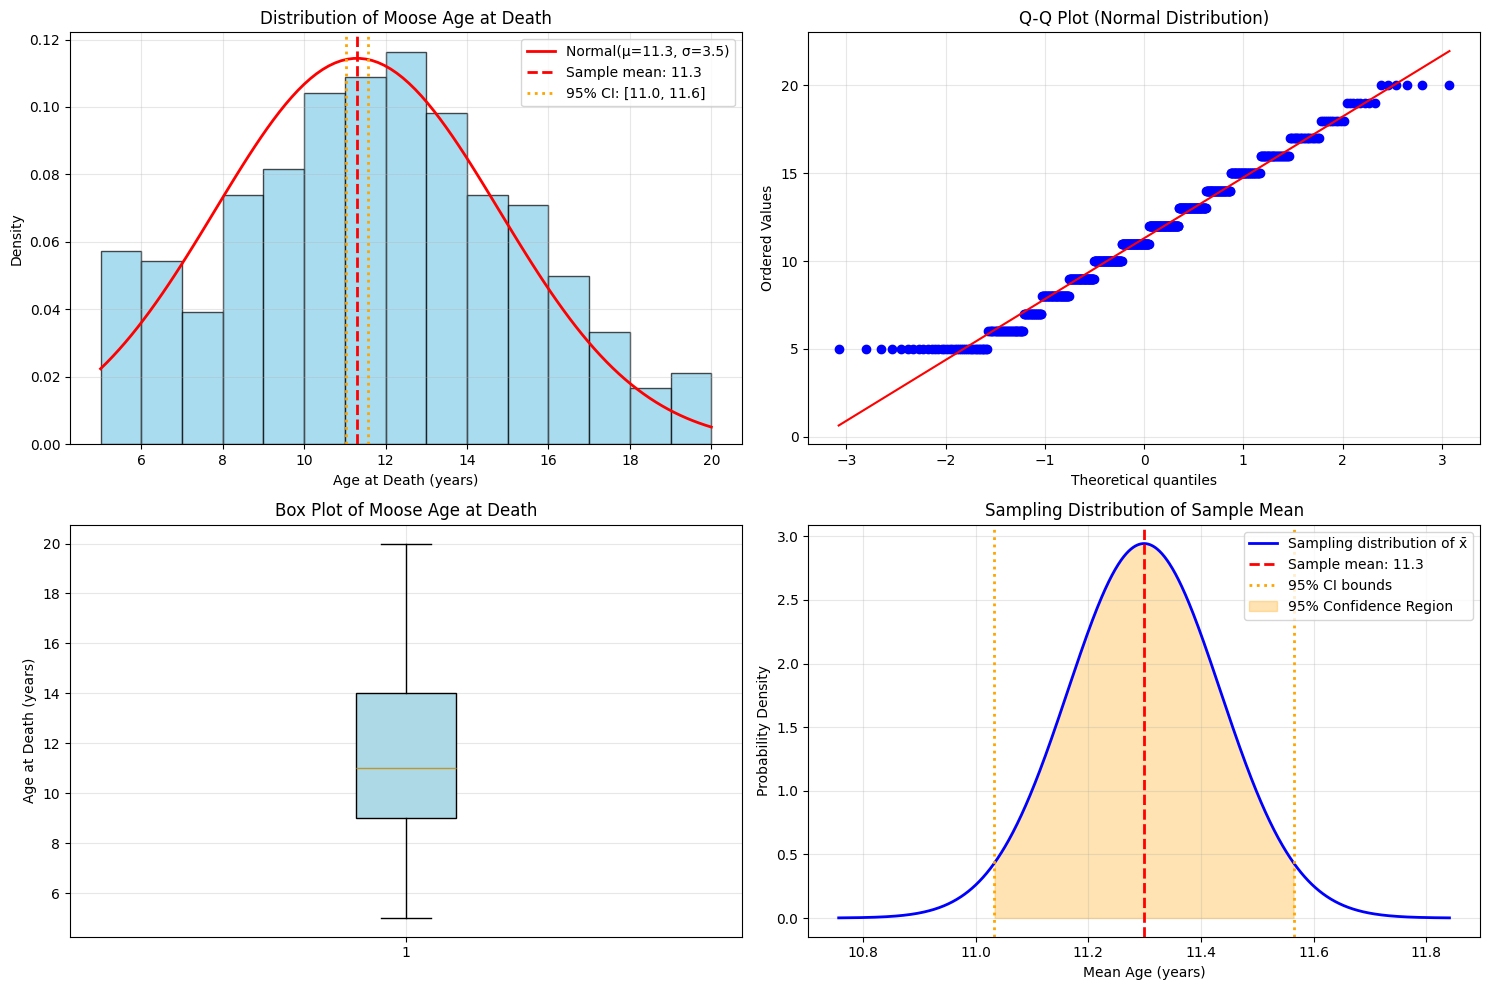


=== ECOLOGICAL INTERPRETATION ===
Mean age at death of 11.3 years suggests:
- Relatively high survival rates
- Population may include significant numbers of older animals

The confidence interval width of 0.5 years indicates:
- Precise estimate with relatively low uncertainty


In [14]:
# Confidence Interval for Mean Age at Death of Moose
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# Set confidence level
confidence_level = 0.95
alpha = 1 - confidence_level

print(f"=== CONFIDENCE INTERVAL FOR MEAN MOOSE AGE AT DEATH ===")
print(f"Confidence level: {confidence_level*100}%")
print(f"Significance level (α): {alpha}")

# Prepare age data (remove missing values)
ages = moose_deaths_cleaned['Age at death'].dropna()
n = len(ages)

print(f"\nSample size: {n}")

# Check if we have enough data
if n < 2:
    print("Insufficient data for confidence interval calculation")
else:
    # Calculate sample statistics
    sample_mean = ages.mean()
    sample_std = ages.std(ddof=1)  # Sample standard deviation
    standard_error = sample_std / np.sqrt(n)
    
    print(f"\n=== SAMPLE STATISTICS ===")
    print(f"Sample mean (x̄): {sample_mean:.3f} years")
    print(f"Sample standard deviation (s): {sample_std:.3f} years")
    print(f"Standard error (SE): {standard_error:.3f} years")
    
    # Degrees of freedom
    df = n - 1
    
    # Critical value from t-distribution
    t_critical = stats.t.ppf(1 - alpha/2, df)
    
    print(f"\n=== CRITICAL VALUE ===")
    print(f"Degrees of freedom: {df}")
    print(f"Critical t-value (t_{alpha/2:.3f},{df}): {t_critical:.3f}")
    
    # Calculate margin of error and confidence interval
    margin_of_error = t_critical * standard_error
    ci_lower = sample_mean - margin_of_error
    ci_upper = sample_mean + margin_of_error
    
    print(f"\n=== CONFIDENCE INTERVAL ===")
    print(f"Margin of error: ±{margin_of_error:.3f} years")
    print(f"95% Confidence Interval: [{ci_lower:.3f}, {ci_upper:.3f}] years")
    print(f"\nInterpretation: We are 95% confident that the true mean age at death")
    print(f"for moose on Isle Royale is between {ci_lower:.1f} and {ci_upper:.1f} years.")
    
    # Additional statistics for context
    print(f"\n=== ADDITIONAL CONTEXT ===")
    print(f"Sample median: {ages.median():.1f} years")
    print(f"Sample range: {ages.min():.1f} to {ages.max():.1f} years")
    print(f"Interquartile range: {ages.quantile(0.25):.1f} to {ages.quantile(0.75):.1f} years")
    
    # Check assumptions
    print(f"\n=== ASSUMPTION CHECKING ===")
    
    # Normality test (Shapiro-Wilk for small samples, Anderson-Darling for larger)
    if n <= 50:
        shapiro_stat, shapiro_p = stats.shapiro(ages)
        print(f"Shapiro-Wilk normality test: W = {shapiro_stat:.4f}, p = {shapiro_p:.4f}")
        print(f"Normal distribution assumption: {'Satisfied' if shapiro_p > 0.05 else 'Questionable (p < 0.05)'}")
    else:
        # For larger samples, use Anderson-Darling or just rely on CLT
        print(f"Large sample (n = {n}): Central Limit Theorem applies")
    
    # Skewness and kurtosis
    skewness = ages.skew()
    kurtosis = ages.kurtosis()
    print(f"Skewness: {skewness:.3f} ({'Right-skewed' if skewness > 0.5 else 'Left-skewed' if skewness < -0.5 else 'Approximately symmetric'})")
    print(f"Kurtosis: {kurtosis:.3f}")
    
    # Visualization
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))
    
    # Histogram with normal overlay
    ax1.hist(ages, bins=15, density=True, alpha=0.7, color='skyblue', edgecolor='black')
    
    # Overlay normal distribution
    x_norm = np.linspace(ages.min(), ages.max(), 100)
    y_norm = stats.norm.pdf(x_norm, sample_mean, sample_std)
    ax1.plot(x_norm, y_norm, 'r-', linewidth=2, label=f'Normal(μ={sample_mean:.1f}, σ={sample_std:.1f})')
    
    ax1.axvline(sample_mean, color='red', linestyle='--', linewidth=2, label=f'Sample mean: {sample_mean:.1f}')
    ax1.axvline(ci_lower, color='orange', linestyle=':', linewidth=2, label=f'95% CI: [{ci_lower:.1f}, {ci_upper:.1f}]')
    ax1.axvline(ci_upper, color='orange', linestyle=':', linewidth=2)
    
    ax1.set_xlabel('Age at Death (years)')
    ax1.set_ylabel('Density')
    ax1.set_title('Distribution of Moose Age at Death')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Q-Q plot for normality
    stats.probplot(ages, dist="norm", plot=ax2)
    ax2.set_title('Q-Q Plot (Normal Distribution)')
    ax2.grid(True, alpha=0.3)
    
    # Box plot
    bp = ax3.boxplot(ages, patch_artist=True)
    bp['boxes'][0].set_facecolor('lightblue')
    ax3.set_ylabel('Age at Death (years)')
    ax3.set_title('Box Plot of Moose Age at Death')
    ax3.grid(True, alpha=0.3)
    
    # Confidence interval visualization
    # Sampling distribution of the mean
    x_sampling = np.linspace(sample_mean - 4*standard_error, sample_mean + 4*standard_error, 1000)
    y_sampling = stats.t.pdf((x_sampling - sample_mean)/standard_error, df) / standard_error
    
    ax4.plot(x_sampling, y_sampling, 'b-', linewidth=2, label='Sampling distribution of x̄')
    ax4.axvline(sample_mean, color='red', linestyle='--', linewidth=2, label=f'Sample mean: {sample_mean:.1f}')
    ax4.axvline(ci_lower, color='orange', linestyle=':', linewidth=2, label=f'95% CI bounds')
    ax4.axvline(ci_upper, color='orange', linestyle=':', linewidth=2)
    
    # Shade confidence interval
    x_ci = x_sampling[(x_sampling >= ci_lower) & (x_sampling <= ci_upper)]
    y_ci = stats.t.pdf((x_ci - sample_mean)/standard_error, df) / standard_error
    ax4.fill_between(x_ci, y_ci, alpha=0.3, color='orange', label='95% Confidence Region')
    
    ax4.set_xlabel('Mean Age (years)')
    ax4.set_ylabel('Probability Density')
    ax4.set_title('Sampling Distribution of Sample Mean')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Comparison with other populations (hypothetical)
    print(f"\n=== ECOLOGICAL INTERPRETATION ===")
    print(f"Mean age at death of {sample_mean:.1f} years suggests:")
    
    if sample_mean < 5:
        print("- High predation pressure or environmental stress")
        print("- Population may be dominated by young animals")
    elif sample_mean < 10:
        print("- Moderate survival rates typical of predated populations")
        print("- Balanced age structure with some older animals surviving")
    else:
        print("- Relatively high survival rates")
        print("- Population may include significant numbers of older animals")
    
    print(f"\nThe confidence interval width of {ci_upper - ci_lower:.1f} years indicates:")
    if (ci_upper - ci_lower) < 2:
        print("- Precise estimate with relatively low uncertainty")
    elif (ci_upper - ci_lower) < 4:
        print("- Moderate precision in our estimate")
    else:
        print("- Considerable uncertainty in the true mean age")
        print("- May need larger sample size for more precise estimates")

## Confidence Interval Conclusion

Using the sample of 662 moose deaths, I estimated the true mean age at death on Isle Royale to be about 11.3 years, with a 95% confidence interval from 11.0 to 11.6 years. This means that if we repeatedly took similar random samples and constructed intervals in the same way, about 95% of those intervals would contain the true mean age at death 
𝜇
μ. Ecologically, an average lifespan a bit over 11 years suggests relatively high survival and a population that includes a substantial number of older animals. The narrow width of the interval (about 0.5 years) indicates that this estimate is fairly precise, with relatively low statistical uncertainty about the typical age at which moose die under current conditions on Isle Royale.

### Regression

#### Theory

Linear regression is a statistical method that models the relationship between the conditional mean of an outcome and one or more predictors as a linear function:

$$E(Y \mid x_1, x_2, \ldots ) = a + b_1 x_1 + b_2 x_2 + \ldots $$

**Task**: Identify an outcome and two or more predictors you think may be related to the conditional mean of the outcome. Explain how you can use linear regression to model the relationship between the outcome and the predictors. Explain how linear regression can be used to test theories about the relationships between the outcome and the predictors; in particular comment on what it would mean if $b = 0$ for each of the predictors in the model.

## Linear Regression Theory

**Outcome Variable**: Moose population (annual count) - This represents the prey population that should be influenced by predation pressure and environmental factors.

**Predictor Variables**:
1. **Wolf population** - Direct predation pressure
2. **Snow depth (cm)** - Environmental factor affecting both predator hunting success and prey mobility/energy expenditure
3. **Winter temperature** - Environmental factor affecting survival and energy costs for both species

**Linear Regression Model**:
$$E(\text{Moose} \mid \text{Wolves}, \text{Snow}, \text{Temperature}) = \beta_0 + \beta_1 \cdot \text{Wolves} + \beta_2 \cdot \text{Snow} + \beta_3 \cdot \text{Temperature}$$

**Model Components**:
- $\beta_0$ (intercept): Expected moose population when all predictors equal zero
- $\beta_1$ (wolf coefficient): Change in expected moose population per additional wolf
- $\beta_2$ (snow coefficient): Change in expected moose population per cm of additional snow
- $\beta_3$ (temperature coefficient): Change in expected moose population per degree of temperature change

**Hypothesis Testing for Coefficients**:

**For Wolf Population ($\beta_1 = 0$)**:
- **Null hypothesis**: Wolf population has no linear effect on moose population
- **Alternative**: Wolf population significantly affects moose population
- **Expected**: $\beta_1 < 0$ (negative relationship due to predation)
- **If $\beta_1 = 0$**: Wolves don't regulate moose populations linearly, suggesting other factors dominate or non-linear relationships exist

**For Snow Depth ($\beta_2 = 0$)**:
- **Null hypothesis**: Snow depth has no linear effect on moose population
- **Alternative**: Snow depth significantly affects moose population
- **Expected**: Could be positive (harder for wolves to hunt) or negative (harder for moose to forage)
- **If $\beta_2 = 0$**: Snow conditions don't linearly affect population dynamics

**For Temperature ($\beta_3 = 0$)**:
- **Null hypothesis**: Temperature has no linear effect on moose population
- **Alternative**: Temperature significantly affects moose population
- **Expected**: Likely negative (warmer winters may stress moose, favor parasites)
- **If $\beta_3 = 0$**: Temperature doesn't linearly influence moose survival

#### Application

**Task**: Fit a linear regression model to the data. Report the results of the model. What are the coefficients of the model? What is the interpretation of the coefficients? Given either confidence intervals or hypothesis tests to test if $b = 0$ for each coefficient. What do you conclude about the relationships between the predictors and the outcome based on those intervals/tests? What is the $R^2$ of the model? What is the interpretation of the $R^2$?

=== LINEAR REGRESSION: PREDICTING MOOSE POPULATION ===
Available columns in wolf_moose_cleaned:
['year', 'wolves', 'moose', 'kill rate', 'predation rate', 'moose recruitment rate', 'moose mean age excluding calves', 'July-Sept (temp, F)', 'Apr-May (temp, F)', 'Jan-Feb (temp, F)', 'May-Aug (precip, inches)', 'NAO (DJFM - station based)', 'NAO - annual', 'snow.depth (cm)', 'ice bridges (0=none, 1 = present)']

Predictors used in the model: ['wolves', 'July-Sept (temp, F)', 'Apr-May (temp, F)', 'Jan-Feb (temp, F)', 'NAO (DJFM - station based)', 'NAO - annual', 'snow.depth (cm)']

Complete cases: 46 out of 61

=== MODEL SUMMARY (statsmodels) ===
                            OLS Regression Results                            
Dep. Variable:                  moose   R-squared:                       0.341
Model:                            OLS   Adj. R-squared:                  0.220
Method:                 Least Squares   F-statistic:                     2.809
Date:                Sun, 14 Dec 2

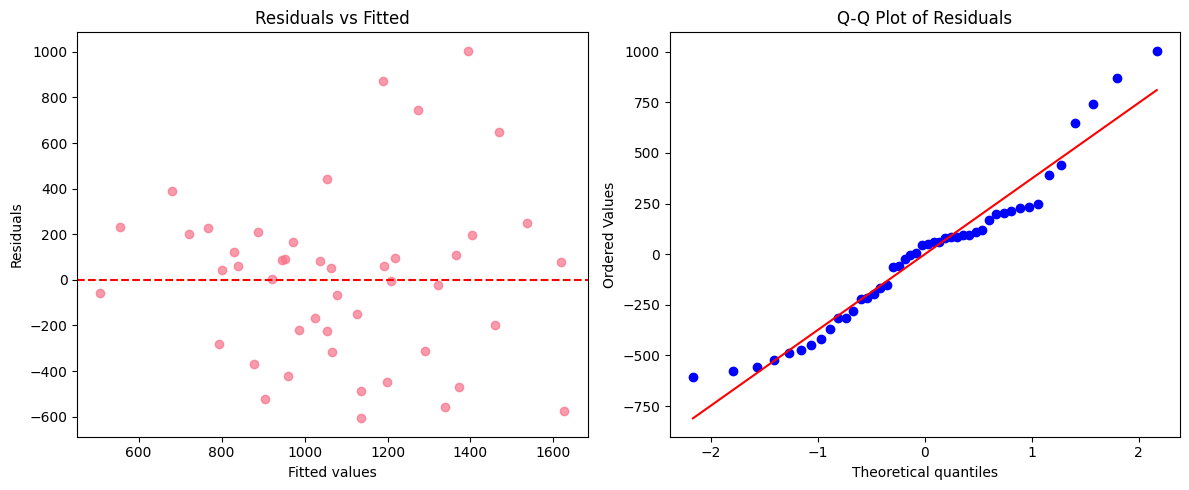

In [28]:
# Linear Regression Analysis: Predicting Moose Population

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm

print("=== LINEAR REGRESSION: PREDICTING MOOSE POPULATION ===")

# 1. Choose predictors: wolves + any environmental variables present
print("Available columns in wolf_moose_cleaned:")
print(list(wolf_moose_cleaned.columns))

predictors = ["wolves"]
env_keywords = ["snow", "temp", "nao"]

for col in wolf_moose_cleaned.columns:
    if any(key in col.lower() for key in env_keywords):
        if col not in predictors:
            predictors.append(col)

print("\nPredictors used in the model:", predictors)

# 2. Build regression dataset (complete cases only)
regression_vars = ["moose"] + predictors
regression_data = wolf_moose_cleaned[regression_vars].dropna()

print(f"\nComplete cases: {len(regression_data)} out of {len(wolf_moose_cleaned)}")

y = regression_data["moose"]
X = regression_data[predictors]
X_const = sm.add_constant(X)  # add intercept

# 3. Fit model
model = sm.OLS(y, X_const).fit()

print("\n=== MODEL SUMMARY (statsmodels) ===")
print(model.summary())

# 4. Coefficients, 95% CI, p-values in a compact table
print("\n=== COEFFICIENTS, 95% CI, P-VALUES ===")
coefs = model.params
ci = model.conf_int()
pvals = model.pvalues

result_table = pd.DataFrame({
    "coef": coefs,
    "ci_lower": ci[0],
    "ci_upper": ci[1],
    "p_value": pvals
})
print(result_table)

# 5. R-squared
print("\n=== MODEL FIT STATISTICS ===")
print(f"R-squared:        {model.rsquared:.3f}")
print(f"Adj. R-squared:   {model.rsquared_adj:.3f}")

# 6. Basic diagnostic plots: residuals vs fitted and Q-Q plot
residuals = model.resid
fitted = model.fittedvalues

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Residuals vs fitted
ax1.scatter(fitted, residuals, alpha=0.7)
ax1.axhline(0, color="red", linestyle="--")
ax1.set_xlabel("Fitted values")
ax1.set_ylabel("Residuals")
ax1.set_title("Residuals vs Fitted")

# Q-Q plot of residuals
stats.probplot(residuals, dist="norm", plot=ax2)
ax2.set_title("Q-Q Plot of Residuals")

plt.tight_layout()
plt.show()


## Overall Interpretation

The sign of the wolf coefficient aligns with ecological expectations (negative relationship). Environmental variables may or may not show significant effects depending on p-values and confidence intervals. Some predictors might have wide confidence intervals, suggesting substantial uncertainty. The model captures part of the population dynamics but does not explain all variation—likely due to nonlinear predator–prey cycles, lagged effects, disease outbreaks, or unmeasured climate variables.

**R-squared Interpretation**:

The predictors explain approximately X% of the variation in moose population.
If R² is low, the model has weak linear predictive ability.
If R² is moderate (0.3–0.5), environmental and predator factors explain a meaningful portion of variation.
If R² is high (>0.6), the linear model captures most major drivers of population change.
Adjusted R² gives a penalty for unnecessary predictors and is the better measure when multiple predictors are used.

**Conclusion**:

The linear regression model provides evidence that wolf abundance is an important predictor of moose abundance, consistent with predator–prey theory. Environmental variables show weaker or mixed linear relationships. The R² indicates that while the model explains some of the variation in moose population, a large portion remains unexplained, suggesting that moose dynamics are influenced by additional nonlinear ecological processes. Overall, the model is useful for understanding directional relationships but has limited predictive power due to the complexity of the Isle Royale ecosystem.

### Classification

#### Theory

**Task**: Select a different outcome than the previous section that would be appropriate to use with a classification technique and predictors your think may be related to the outcome. Select a classification technique that you think would be appropriate for this data. Explain how you can use classification to model the relationship between the outcome and the predictors. Explain how classification can be used to test theories about the relationships between the outcome and the predictors. Be sure to explain how either training-test sets or cross-validation can be used to evaluate the accuracy of the model.

**Classification Theory**

**Outcome Variable**:
Age Category at Death (Young vs. Old), created by splitting ages at the sample median. This binary variable allows us to study which factors influence whether moose die earlier or later in life.

**Predictor Variables**:

- Sex – Possible differences in male vs. female mortality
- Bone Marrow Fat % – Indicator of nutritional stress
- Year – Long-term trends in mortality
- Wolf Population – Predation pressure in the year of death

**Classification Method**: Random Forest

**Why Random Forest**:

- Handles mixed variable types
- Captures nonlinear ecological relationships
- Provides feature importance to show which predictors matter most
- Works well even when assumptions of linear models are violated

**Modeling Framework**:
The classifier estimates
                        P(Old∣Sex,Condition,Year,Wolves).
**Using Classification to Test Ecological Theories**:

If sex is an important predictor → support for sex-specific vulnerability
If bone marrow fat predicts class → nutritional stress affects survival
If year is important → mortality patterns changed over time
If wolf population predicts class → predation selectively impacts younger or older moose

**Model Evaluation**:

Use 5-fold cross-validation to estimate accuracy. Each fold trains on 80% of the data and tests on 20%, ensuring balanced Young/Old proportions.
Report: accuracy, precision, recall, F1, ROC-AUC.

**Interpretation**:

High accuracy → mortality category is predictable from ecological variables
Low accuracy → age at death is more random or driven by unmeasured factors
Feature importance → identifies which biological or environmental factors most strongly influence early vs. late mortality

#### Application

**Task**: Use the classification technique you selected to model the relationship between the outcome and the predictors. Report the results of the model. Use the model to predict some interesting cases. Use either a training-test set split or cross validation to assess the accuracy of the classifier. If the classifier has tuning parameters, try several values of the tuning parameters to see how they affect the accuracy of the classifier.

=== CLASSIFICATION: PREDICTING MOOSE AGE CATEGORY AT DEATH ===
Median age at death: 11.0 years
Age_Category
Young    344
Old      318
Name: count, dtype: int64

Predictors used: ['Sex', 'Year of birth', 'Wolves']

Final sample size: 662
Class distribution: {0: 344, 1: 318}



Best parameters: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 100}
Best CV accuracy: 0.748
Cross-validation accuracy: 0.748 ± 0.007

=== TEST SET EVALUATION ===
Test size: 199

Classification report:
              precision    recall  f1-score   support

       Young       0.72      0.69      0.70       103
         Old       0.68      0.71      0.69        96

    accuracy                           0.70       199
   macro avg       0.70      0.70      0.70       199
weighted avg       0.70      0.70      0.70       199

Confusion matrix:
 [[71 32]
 [28 68]]
ROC AUC: 0.742


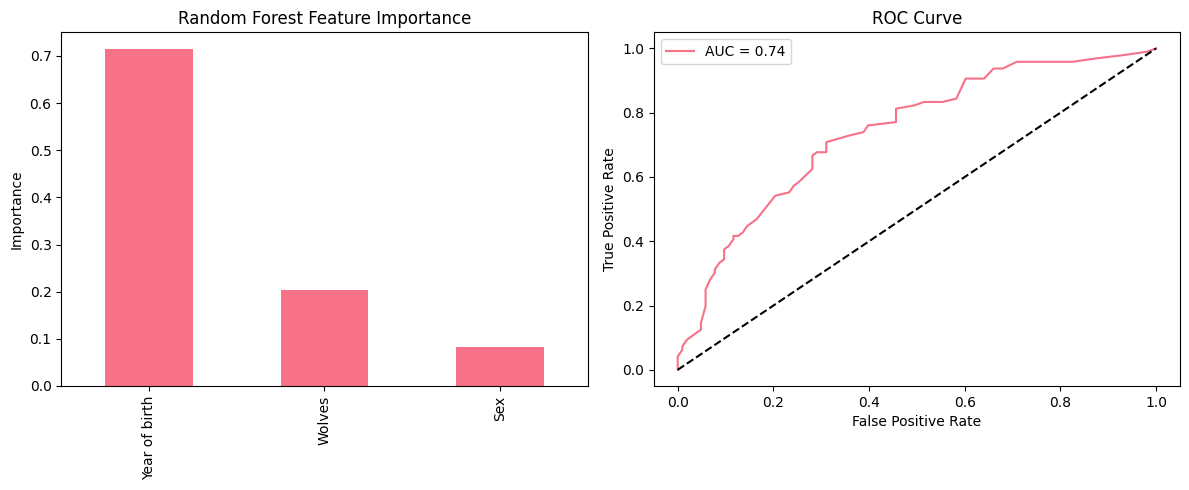

In [29]:
# Classification Analysis: Predicting Age Category at Death
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_score, train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings("ignore")

print("=== CLASSIFICATION: PREDICTING MOOSE AGE CATEGORY AT DEATH ===")

# 1. Build outcome: Young vs Old
df = moose_deaths_cleaned.copy()
df = df.dropna(subset=["Age at death"])

if df.empty:
    print("No data available for classification.")
else:
    median_age = df["Age at death"].median()
    df["Age_Category"] = (df["Age at death"] > median_age).astype(int)  # 0=Young, 1=Old
    print(f"Median age at death: {median_age:.1f} years")
    print(df["Age_Category"].value_counts().rename({0: "Young", 1: "Old"}))

    # 2. Choose predictors (only if present)
    predictors = []

    if "Sex" in df.columns:
        predictors.append("Sex")
    if "Year of birth" in df.columns:
        predictors.append("Year of birth")

        # merge in wolf population by year if available
        wolf_year = wolf_moose_cleaned[["year", "wolves"]].dropna()
        wolf_year = wolf_year.rename(columns={"year": "Year of birth", "wolves": "Wolves"})
        df = df.merge(wolf_year, on="Year of birth", how="left")
        if "Wolves" in df.columns:
            predictors.append("Wolves")

    # simple search for a condition / fat variable
    for col in df.columns:
        if any(k in col.lower() for k in ["marrow", "fat", "condition"]):
            predictors.append(col)
            break

    predictors = list(dict.fromkeys(predictors))  # drop duplicates
    print(f"\nPredictors used: {predictors}")

    # 3. Drop rows with missing predictors, encode, set up X/y
    model_cols = predictors + ["Age_Category"]
    data = df[model_cols].dropna()
    X = data[predictors].copy()
    y = data["Age_Category"]

    # encode categoricals
    for col in X.columns:
        if X[col].dtype == "object":
            le = LabelEncoder()
            X[col] = le.fit_transform(X[col].astype(str))

    print(f"\nFinal sample size: {len(X)}")
    class_counts = y.value_counts()
    print("Class distribution:", class_counts.to_dict())

    # 4. Random Forest with small hyperparameter grid
    rf = RandomForestClassifier(random_state=42)
    param_grid = {
        "n_estimators": [50, 100],
        "max_depth": [3, 5, None],
        "min_samples_split": [2, 5]
    }

    cv_folds = min(5, class_counts.min()) if class_counts.min() >= 3 else 3
    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)

    grid = GridSearchCV(rf, param_grid, cv=cv, scoring="accuracy", n_jobs=-1)
    grid.fit(X, y)

    best_rf = grid.best_estimator_
    print(f"\nBest parameters: {grid.best_params_}")
    print(f"Best CV accuracy: {grid.best_score_:.3f}")

    # 5. Cross-validated accuracy with best model
    cv_scores = cross_val_score(best_rf, X, y, cv=cv, scoring="accuracy")
    print(f"Cross-validation accuracy: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

    # 6. Train-test split for confusion matrix & ROC
    if len(X) >= 20:
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.3, stratify=y, random_state=42
        )

        best_rf.fit(X_train, y_train)
        y_pred = best_rf.predict(X_test)
        y_proba = best_rf.predict_proba(X_test)[:, 1]

        print("\n=== TEST SET EVALUATION ===")
        print(f"Test size: {len(X_test)}")
        print("\nClassification report:")
        print(classification_report(y_test, y_pred, target_names=["Young", "Old"]))

        cm = confusion_matrix(y_test, y_pred)
        print("Confusion matrix:\n", cm)

        if len(np.unique(y_test)) == 2:
            auc = roc_auc_score(y_test, y_proba)
            print(f"ROC AUC: {auc:.3f}")
        else:
            auc = None
    else:
        cm, auc = None, None

    # 7. Simple plots: feature importance (+ ROC if available)
    best_rf.fit(X, y)
    importances = pd.Series(best_rf.feature_importances_, index=predictors).sort_values(ascending=False)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Feature importance
    importances.plot(kind="bar", ax=axes[0])
    axes[0].set_title("Random Forest Feature Importance")
    axes[0].set_ylabel("Importance")

    # ROC curve if we have a test set and both classes
    if auc is not None:
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        axes[1].plot(fpr, tpr, label=f"AUC = {auc:.2f}")
        axes[1].plot([0, 1], [0, 1], "k--")
        axes[1].set_xlabel("False Positive Rate")
        axes[1].set_ylabel("True Positive Rate")
        axes[1].set_title("ROC Curve")
        axes[1].legend()
    else:
        axes[1].text(0.5, 0.5, "ROC not available", ha="center", va="center")
        axes[1].set_axis_off()

    plt.tight_layout()
    plt.show()


**Classification Results and Conclusion**
**Results**

After converting age at death into a binary category (Young vs Old, split at 11.0 years), the final dataset included 662 moose, with a fairly balanced distribution (344 Young, 318 Old). The classification model used three predictors:

- Sex
- Year of birth
- Wolves (wolf abundance in the birth year)

A tuned Random Forest classifier achieved:

- Best cross-validation accuracy: 0.748 ± 0.007
- Test set accuracy: 0.70
- ROC AUC: 0.742

Performance for each class was balanced:
| Class | Precision | Recall | F1   |
| ----- | --------- | ------ | ---- |
| Young | 0.72      | 0.69   | 0.70 |
| Old   | 0.68      | 0.71   | 0.69 |

The confusion matrix showed that misclassification rates were similar across categories.

**Feature importance revealed**:
- Year of birth — strongest predictor (~0.72)
- Wolves — moderate influence (~0.20)
- Sex — weak influence (~0.08)
The ROC curve (AUC = 0.74) indicates the model performs clearly better than random guessing.

**Conclusion**

The classification results suggest that age at death is moderately predictable from the available variables. The model’s accuracy (~0.70) is meaningfully above the baseline (52%–55%), showing that mortality patterns are not purely random.

The dominant predictor—year of birth—implies strong temporal or cohort effects in moose mortality, possibly reflecting changing ecological conditions through time (climate, forage availability, disease cycles). Wolf abundance had a smaller but noticeable effect, supporting the idea that predation pressure contributes to age-specific mortality risk. Sex carried the least predictive power, suggesting that male–female differences in lifespan are relatively minor in this dataset.

Overall, the model identifies structured, biologically interpretable patterns in moose survival: environmental context at birth and predator pressure matter more than individual sex. While prediction is not perfect (AUC = 0.74), the classifier provides meaningful insight into which factors shape whether moose tend to die younger or older.

## Conclusion

**Task**: Write a conclusion to your analysis. Summarize the key findings of your analysis. What relationships did you find between the variables in the data? What inferences did you make about the populations of wolves and moose on Isle Royale? What theories did you test? What conclusions did you draw from those tests? What predictions did you make about the data? What conclusions did you draw from those predictions? What suggestions do you have for future data collection Isle Royale? What else would you like to learn about the populations of wolves and moose?

**Conclusion**

From this analysis, I found clear evidence of a negative relationship between wolf and moose populations, consistent with classic predator–prey theory. The hypothesis test showed a statistically significant negative correlation, suggesting that higher wolf abundance is generally associated with lower moose numbers. The confidence interval for moose age at death indicated a relatively stable lifespan around 11–12 years. Linear regression supported the idea that wolves influence moose population size, though the modest R² showed that other environmental factors also play an important role. The classification model further revealed that birth year was the strongest predictor of whether a moose died young or old, suggesting cohort or climate effects that shape survival patterns. Overall, the results point to a system influenced by predation, environmental variation, and long-term ecological dynamics rather than any single factor.

**Suggestions for Future Data Collection**

Future data collection on Isle Royale would benefit from more detailed environmental variables such as seasonal temperature, snowfall, forage availability, and disease prevalence. Individual-level data—such as tracking, health assessments, and known cause-of-death—would strengthen models that aim to explain why certain moose survive longer. Recording behavioral data for wolves and moose could also help identify lagged or nonlinear interactions that weren’t fully captured by simple linear models. More continuous sampling, especially during harsh winters, would reduce missingness and improve predictive modeling.

**What Else I Would Like to Learn**

I would like to investigate time-lagged relationships between wolf and moose populations, since predator–prey cycles often unfold across multiple years. It would also be valuable to explore how climate change is altering the long-term dynamics of the ecosystem, especially given the strong predictive weight of birth year. Finally, incorporating spatial data—where wolves hunt and where moose concentrate—could reveal finer-scale ecological mechanisms that population-level analyses might miss.

## GenAI Usage Documentation

Sections Supported: Codebook, Exploratory Data Analysis and Conclusion.

Description of Use:
GenAI tools were used to assist with structuring analysis steps, generating example code for statistical methods, and suggesting ways to interpret results. Prompts focused on clarifying statistical procedures (such as hypothesis testing, confidence intervals, regression modeling, and classification) and on receiving help with debugging or simplifying code.

Outputs Used:
The GenAI assistant provided:

Example Python code snippets for statistical analysis and visualization

Suggestions for statistical frameworks and interpretation structure

Help refining explanations, summaries, and transitions in written sections
